In [49]:
# =========================================================
# COMMON CODE FOR HORSE AUCTION PRICE PREDICTION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("="*70)
print("LINEAR REGRESSION MODEL")
print("="*70)


# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------
def find_col(df, candidates):
    """Find column by exact, case-insensitive, or substring match."""
    cols = list(df.columns)
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def to_numeric_safe(series):
    """Convert series to numeric, handling various formats."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace("\u00a0", "", regex=False)
              .str.replace(" ", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )



# ---------------------------------------------------------
# Load and prepare data
# ---------------------------------------------------------
print("="*70)
print("DATA PREPARATION")
print("="*70)

df = pd.read_excel("GAM.xlsx")
df.columns = [c.strip() for c in df.columns]
print(f"\nLoaded {len(df)} rows")

# Identify columns
col_price = find_col(df, ["Sales Price", "Hammer Price", "Price"])
col_studfee = find_col(df, ["Sire Stud Fee", "Stud Fee"])
col_dam_earnings = find_col(df, ["Dam Earnings"])
col_dam_best = find_col(df, ["Dam Best Time", "Dam Best"])
col_dam_starts = find_col(df, ["Dam Starts"])
col_dam_1st = find_col(df, ["Dam 1st"])
col_dam_age = find_col(df, ["Dam Age"])
col_age = find_col(df, ["Age in days", "Age"])
col_year = find_col(df, ["Year", "Auction Year"])
col_gender = find_col(df, ["Gender", "Sex"])
col_auction = find_col(df, ["Auction", "Auction House"])
col_siblings_raceage = find_col(df, ["Siblings Raceage"])
col_american_stakes = "American Stakes"  
col_surgery_report = "Surgery Certificate"
col_surgery_severity = "Surgery Severity"
col_xray_status = 'OCD_XRAY'
col_xray_remains = 'Xray_REM'
col_breeder = 'Breeder'
col_sire_first_season = find_col(df, ["First_Season_Flag"])
col_sire_starts = find_col(df, ["Sire Starts"])
col_sire_earnings = find_col(df, ["Sire Earnings"]) 
col_sire_1st = find_col(df, ["Sire 1st"])
col_dam_sire = find_col(df, ["Dams_Sire"])

# BLUP columns
col_dam_blup = find_col(df, ["Dam BLUP", "Dam_BLUP", "DamBLUP"])
col_sire_blup = find_col(df, ["Sire BLUP", "Sire_BLUP", "SireBLUP"])
col_dam_sire_blup = find_col(df, ["Dam Sire BLUP", "Dam_Sire_BLUP", "DamSireBLUP", "Damsire BLUP"])

print(f"\n[BLUP COLUMNS FOUND]")
print(f"  Dam BLUP:      {col_dam_blup}")
print(f"  Sire BLUP:     {col_sire_blup}")
print(f"  Dam Sire BLUP: {col_dam_sire_blup}")



# ---------------------------------------------------------
# Convert columns to numeric
# ---------------------------------------------------------
print("\n[CONVERTING COLUMNS TO NUMERIC]")
numeric_candidates = [
    col_price, col_studfee, col_dam_earnings, col_dam_best, 
    col_dam_starts, col_dam_1st, col_dam_age, col_age, col_siblings_raceage,
    "French Blood", "Inbreeding", "Sibling Earnings", "Sibling Starts",
    "Sibling 1st", "Gdam  Earnings", "Gdam Raceage", "Gdam Offspring 1st",
    "Gdam Offspring Starts", "Ggdam Earnings", "Ggdam Raceage",
    "Ggdam Offspring 1st", "Ggdam Offspring Starts",
    col_dam_blup, col_sire_blup, col_dam_sire_blup,  
    col_surgery_report, col_surgery_severity, col_xray_remains,
    col_american_stakes, col_sire_starts, col_sire_earnings, col_sire_1st
]

for col in numeric_candidates:
    if col and col in df.columns:
        if df[col].dtype == 'object':
            print(f"  Converting: {col}")
        df[col] = to_numeric_safe(df[col])

# Target variable
df["log_price"] = np.log(df[col_price])

#Log transform Stud fee 
df["log_stud_fee"] = np.log(df[col_studfee])



# ---------------------------------------------------------
# Feature Engineering
# ---------------------------------------------------------
print("\n[FEATURE ENGINEERING]")

# Dam performance - KEEP NaN for XGBoost to handle
# Only calculate if dam has raced
df["DamWinPct"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_1st] / df[col_dam_starts],
    np.nan  # Let XGBoost handle missing
)

# Binary indicator for dam never raced
df["Dam_Never_Raced"] = (df[col_dam_starts].isna() | (df[col_dam_starts] == 0)).astype(int)


# Dam earnings pr start 
df["DamEarningsPerStart"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_earnings] / df[col_dam_starts],
    np.nan
)

# Sibling performance - KEEP NaN for missing
df["SiblingEarningsPerStart"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling Earnings"] / df["Sibling Starts"],
    np.nan
)

df["SiblingEarningsPerHorse"] = np.where(
    df[col_siblings_raceage] > 0,
    df["Sibling Earnings"] / df[col_siblings_raceage],
    np.nan
)

df["SiblingWinPct"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling 1st"] / df["Sibling Starts"],
    np.nan
)

# Binary indicator for no siblings
df["Siblings_Missing"] = (df[col_siblings_raceage].isna() | (df[col_siblings_raceage] == 0)).astype(int)

# Granddam performance
df["GranddamEarningsPerHorse"] = np.where(
    df["Gdam Raceage"] > 0,
    df["Gdam  Earnings"] / df["Gdam Raceage"],
    np.nan
)

df["GranddamWinPct"] = np.where(
    df["Gdam Offspring Starts"] > 0,
    df["Gdam Offspring 1st"] / df["Gdam Offspring Starts"],
    np.nan
)

# Great-granddam performance
df["GD_Dam_EarningsPerHorse"] = np.where(
    df["Ggdam Raceage"] > 0,
    df["Ggdam Earnings"] / df["Ggdam Raceage"],
    np.nan
)

df["GD_Dam_WinPct"] = np.where(
    df["Ggdam Offspring Starts"] > 0,
    df["Ggdam Offspring 1st"] / df["Ggdam Offspring Starts"],
    np.nan
)


# Sire performance

df["SireWinPct"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_1st] / df[col_sire_starts],
    np.nan
)

df["SireEarningsPerStart"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_earnings] / df[col_sire_starts],
    np.nan
)

#Inverse dam time so that sign is interpretable 
df['dam_time_inverse'] = 1 / df['Dam Best Time']

# Prize money impact 
prize_money_sek = {
    2023: 1.0,
    2024: 1.02,
    2025: 1.1
}

df["Prize_Money_Factor"] = df[col_year].map({2023: 1.0, 2024: 1.02, 2025: 1.1})


# BLUP missing indicators
if col_dam_blup and col_dam_blup in df.columns:
    df["Dam_BLUP_Missing"] = df[col_dam_blup].isna().astype(int)
if col_sire_blup and col_sire_blup in df.columns:
    df["Sire_BLUP_Missing"] = df[col_sire_blup].isna().astype(int)
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    df["Dam_Sire_BLUP_Missing"] = df[col_dam_sire_blup].isna().astype(int)

# Categorical encoding
df[col_auction] = df[col_auction].astype(str).str.strip().str.upper()
df["Selective_Auctions"] = df[col_auction].isin(["EY", "SY"]).astype(int)

df[col_gender] = df[col_gender].astype(str).str.strip().str.upper()
df["Gender"] = (df[col_gender] == "H").astype(int)



# ---------------------------------------------------------
# XRAY_RISK_SCORE (deterministic feature)
# ---------------------------------------------------------
print("  Creating XRAY_RISK_SCORE")

# Ensure numeric types (in case they come in as object)
for c in [col_xray_status, col_surgery_report, col_surgery_severity, col_xray_remains]:
    if c in df.columns:
        df[c] = to_numeric_safe(df[c])

# Normalize: SURGERY_SEVERITY should be NaN when no surgery certificate
# (so '0' doesn't carry meaning beyond "not applicable")
if col_surgery_report in df.columns and col_surgery_severity in df.columns:
    df.loc[df[col_surgery_report] == 0, col_surgery_severity] = np.nan

# Compute score components (monotone, clamped to [0,1])
base_risk = np.where(df[col_xray_status] == 1, 0.40, 0.00)
surgery_mitigation = np.where(df[col_surgery_report] == 1, -0.10, 0.00)

# disease burden: only if severity exists (3-5). If NaN -> 0.0
# disease burden (severity)

severity_map = {
    3: 0.10,
    4: 0.30,
    5: 0.60
}

severity_risk = df[col_surgery_severity].map(severity_map).fillna(0.0)



# residual risk: X_RAY_REM assumed 0-3; if missing -> 0 (or NaN if you prefer)
rem = df[col_xray_remains].fillna(0.0)
residual_risk = 0.15 * rem

df["XRAY_RISK_SCORE"] = base_risk + surgery_mitigation + severity_risk + residual_risk
df["XRAY_RISK_SCORE"] = df["XRAY_RISK_SCORE"].clip(lower=0.0, upper=1.0)


print("  Created derived features")


df.to_excel("LINEAR_REGRESSION_ENGINEERED.xlsx", index=True)




LINEAR REGRESSION MODEL
DATA PREPARATION

Loaded 1618 rows

[BLUP COLUMNS FOUND]
  Dam BLUP:      Dam BLUP
  Sire BLUP:     Sire BLUP
  Dam Sire BLUP: Dam Sire BLUP

[CONVERTING COLUMNS TO NUMERIC]
  Converting: French Blood
  Converting: Inbreeding

[FEATURE ENGINEERING]
  Creating XRAY_RISK_SCORE
  Created derived features


In [50]:

# ---------------------------------------------------------
# Train/Test Split
# ---------------------------------------------------------
TRAIN_YEARS = [2023, 2024]
TEST_YEAR = 2025

train_mask = df[col_year].isin(TRAIN_YEARS)
test_mask = df[col_year] == TEST_YEAR

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

y_train = df_train["log_price"].copy()
y_test = df_test["log_price"].copy()

print(f"[SPLIT]")
print(f"  Train: {len(df_train)} rows ({TRAIN_YEARS})")
print(f"  Test: {len(df_test)} rows ({TEST_YEAR})")

[SPLIT]
  Train: 1108 rows ([2023, 2024])
  Test: 510 rows (2025)


In [51]:
# =========================================================
# BREEDER - SMOOTHED TARGET ENCODING (with LOO for training)
# =========================================================

print("="*70)
print("BREEDER - SMOOTHED TARGET ENCODING")
print("="*70)

# ---------------------------------------------------------
# 1. Calculate breeder statistics on TRAINING DATA
# ---------------------------------------------------------
target = 'log_price'

# Global mean from training data
global_mean_breeder = df_train[target].mean()

# Breeder-level statistics from training data
breeder_stats = df_train.groupby(col_breeder)[target].agg(['sum', 'count', 'std'])
breeder_stats.columns = ['breeder_sum', 'n', 'breeder_std']
breeder_stats['breeder_mean'] = breeder_stats['breeder_sum'] / breeder_stats['n']

print(f"\n[BREEDER STATISTICS (from training data)]")
print(f"  Unique breeders in train: {len(breeder_stats)}")
print(f"  Global mean (log_price):  {global_mean_breeder:.4f}")
print(f"\n  Breeder count distribution:")
print(f"    1 horse:     {(breeder_stats['n'] == 1).sum()} breeders")
print(f"    2-5 horses:  {((breeder_stats['n'] >= 2) & (breeder_stats['n'] <= 5)).sum()} breeders")
print(f"    6-10 horses: {((breeder_stats['n'] >= 6) & (breeder_stats['n'] <= 10)).sum()} breeders")
print(f"    11+ horses:  {(breeder_stats['n'] > 10).sum()} breeders")

# ---------------------------------------------------------
# 2. Calculate smoothing parameter (Empirical Bayes)
# ---------------------------------------------------------
global_var = df_train[target].var()
within_var = breeder_stats['breeder_std'].mean() ** 2
m_breeder = global_var / within_var if within_var > 0 else 5

print(f"\n[SMOOTHING PARAMETER]")
print(f"  Empirical Bayes m: {m_breeder:.2f}")

# ---------------------------------------------------------
# 3. TRAINING DATA: Leave-One-Out Encoding
# ---------------------------------------------------------
# For each training horse: exclude its own price from breeder mean

# Map breeder totals to each row
train_breeder_sum = df_train[col_breeder].map(breeder_stats['breeder_sum'])
train_breeder_n = df_train[col_breeder].map(breeder_stats['n'])

# LOO mean: (sum - this_horse_price) / (n - 1)
loo_mean = (train_breeder_sum - df_train[target]) / (train_breeder_n - 1)

# For single-horse breeders, LOO mean is undefined → use global mean
loo_mean = loo_mean.fillna(global_mean_breeder)

# Effective sample size for smoothing
loo_n = (train_breeder_n - 1).clip(lower=0)

# Apply smoothing to LOO means
df_train['Breeder_Encoded'] = (loo_n * loo_mean + m_breeder * global_mean_breeder) / (loo_n + m_breeder)
df_train['Breeder_Encoded'] = df_train['Breeder_Encoded'].fillna(global_mean_breeder)

print(f"\n[TRAINING DATA: Leave-One-Out Encoding Applied]")
print(f"  Each horse's encoding excludes its own price")

# ---------------------------------------------------------
# 4. TEST DATA: Standard Encoding (use full training stats)
# ---------------------------------------------------------
# Test horses were never in training, so no LOO needed

def smoothed_target_encode(df, col, stats, global_mean, m):
    """Apply smoothed target encoding using full breeder stats."""
    n = df[col].map(stats['n']).fillna(0)
    breeder_mean = df[col].map(stats['breeder_mean']).fillna(global_mean)
    encoded = (n * breeder_mean + m * global_mean) / (n + m)
    return encoded.fillna(global_mean)

df_test['Breeder_Encoded'] = smoothed_target_encode(
    df_test, col_breeder, breeder_stats, global_mean_breeder, m_breeder
)

# Check for new breeders in test set
train_breeders = set(df_train[col_breeder].unique())
test_breeders = set(df_test[col_breeder].unique())
new_breeders = test_breeders - train_breeders

print(f"\n[TEST DATA: Standard Encoding Applied]")
print(f"  Uses full training breeder statistics")
print(f"  New breeders in test: {len(new_breeders)} (will use global mean)")

# ---------------------------------------------------------
# 5. Summary statistics
# ---------------------------------------------------------
print(f"\n[ENCODED FEATURE STATISTICS]")
print(f"  Train - Mean: {df_train['Breeder_Encoded'].mean():.4f}, Std: {df_train['Breeder_Encoded'].std():.4f}")
print(f"  Test  - Mean: {df_test['Breeder_Encoded'].mean():.4f}, Std: {df_test['Breeder_Encoded'].std():.4f}")

# ---------------------------------------------------------
# 6. Correlation check
# ---------------------------------------------------------
corr_train = df_train['Breeder_Encoded'].corr(df_train['log_price'])
corr_test = df_test['Breeder_Encoded'].corr(df_test['log_price'])

print(f"\n[CORRELATION WITH log_price]")
print(f"  Train (LOO): r = {corr_train:+.4f}  ← No leakage")
print(f"  Test:        r = {corr_test:+.4f}  ← Out-of-sample")



BREEDER - SMOOTHED TARGET ENCODING

[BREEDER STATISTICS (from training data)]
  Unique breeders in train: 309
  Global mean (log_price):  11.7590

  Breeder count distribution:
    1 horse:     147 breeders
    2-5 horses:  119 breeders
    6-10 horses: 26 breeders
    11+ horses:  17 breeders

[SMOOTHING PARAMETER]
  Empirical Bayes m: 2.22

[TRAINING DATA: Leave-One-Out Encoding Applied]
  Each horse's encoding excludes its own price

[TEST DATA: Standard Encoding Applied]
  Uses full training breeder statistics
  New breeders in test: 61 (will use global mean)

[ENCODED FEATURE STATISTICS]
  Train - Mean: 11.7896, Std: 0.4040
  Test  - Mean: 11.8670, Std: 0.3974

[CORRELATION WITH log_price]
  Train (LOO): r = +0.4021  ← No leakage
  Test:        r = +0.2988  ← Out-of-sample


In [52]:
# Define feature list. Most included by default, comment out the ones that should not be in the model. 
# --------------------------. -------------------------------
FEATURES = [
    # Core features
    "French Blood",
    "Inbreeding",
    "Gender",
    col_age,
    col_american_stakes,
#   col_xray_status,
 #  col_xray_remains,
    "XRAY_RISK_SCORE",

      #Sire Features
    #col_studfee,
    "log_stud_fee",    
   col_sire_first_season,
  #  "SireWinPct",
    "SireEarningsPerStart",
    
    # Dam features
 #   col_dam_earnings,
    "DamEarningsPerStart",
  #  col_dam_best,
    "dam_time_inverse",
    "DamWinPct",
     col_dam_age,
 #   col_dam_starts,
    
    # BLUP features
    col_dam_blup,
    col_dam_sire_blup,
    col_sire_blup,
   
    #  Sibling features
   # "Sibling Earnings",
   # "Sibling Starts",
  #   col_siblings_raceage,
   # "SiblingEarningsPerStart",
    "SiblingEarningsPerHorse",
    "SiblingWinPct",
    
    # Granddam features
   # "Gdam Earnings",
   # "Gdam Raceage",
   "GranddamEarningsPerHorse",
    "GranddamWinPct",
    
    # Great-granddam features
    #"Ggdam Earnings",
    "GD_Dam_EarningsPerHorse",
    "GD_Dam_WinPct",
    
    # Other Categorical/Binary
    "Selective_Auctions",
    "Dam_Never_Raced",
    "Siblings_Missing",
 #   "Prize_Money_Factor"

    # BREEDER (smoothed target encoded)
    "Breeder_Encoded",
]

# Add BLUP missing indicators
if col_dam_blup and col_dam_blup in df.columns:
    FEATURES.append("Dam_BLUP_Missing")
if col_sire_blup and col_sire_blup in df.columns:
   FEATURES.append("Sire_BLUP_Missing")
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    FEATURES.append("Dam_Sire_BLUP_Missing")


# Filter to existing columns
#FEATURES = [f for f in FEATURES if f and f in df.columns]
FEATURES = [f for f in FEATURES if f and f in df_train.columns]

print(f"\n[FEATURES] {len(FEATURES)} features selected")
for f in FEATURES:
    print(f"  - {f}")


# ---------------------------------------------------------
# Create feature matrices
# ---------------------------------------------------------
X_train_raw = df_train[FEATURES].copy()
X_test_raw = df_test[FEATURES].copy()

# Convert any remaining object columns
for col in X_train_raw.columns:
    if X_train_raw[col].dtype == 'object':
        X_train_raw[col] = to_numeric_safe(X_train_raw[col])
        X_test_raw[col] = to_numeric_safe(X_test_raw[col])

# Handle infinities
X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan)
X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)

print(f"\n[FEATURE MATRICES]")
print(f"  X_train: {X_train_raw.shape}")
print(f"  X_test:  {X_test_raw.shape}")


[FEATURES] 29 features selected
  - French Blood
  - Inbreeding
  - Gender
  - Age in days
  - American Stakes
  - XRAY_RISK_SCORE
  - log_stud_fee
  - First_Season_Flag
  - SireEarningsPerStart
  - DamEarningsPerStart
  - dam_time_inverse
  - DamWinPct
  - Dam Age
  - Dam BLUP
  - Dam Sire BLUP
  - Sire BLUP
  - SiblingEarningsPerHorse
  - SiblingWinPct
  - GranddamEarningsPerHorse
  - GranddamWinPct
  - GD_Dam_EarningsPerHorse
  - GD_Dam_WinPct
  - Selective_Auctions
  - Dam_Never_Raced
  - Siblings_Missing
  - Breeder_Encoded
  - Dam_BLUP_Missing
  - Sire_BLUP_Missing
  - Dam_Sire_BLUP_Missing

[FEATURE MATRICES]
  X_train: (1108, 29)
  X_test:  (510, 29)


In [53]:
# =========================================================
# MISSING VALUE IMPUTATION
# =========================================================

print("="*70)
print("SMART MISSING VALUE IMPUTATION")
print("="*70)

# ---------------------------------------------------------
# 1. Informative missingness: Impute with 0
# ---------------------------------------------------------
print("\n[INFORMATIVE MISSINGNESS → IMPUTE WITH 0]")

zero_impute_cols = [
    'SiblingEarningsPerHorse',
    'SiblingEarningsPerStart', 
    'SiblingWinPct',
    'dam_time_inverse',
    'DamEarningsPerStart',
    'DamWinPct',
]

for col in zero_impute_cols:
    if col in X_train_raw.columns:
        n_missing = X_train_raw[col].isna().sum()
        X_train_raw[col] = X_train_raw[col].fillna(0)
        X_test_raw[col] = X_test_raw[col].fillna(0)
        print(f"  {col}: {n_missing} → filled with 0")

# ---------------------------------------------------------
# 2. Regular missingness: Impute with median
# ---------------------------------------------------------
print("\n[REGULAR MISSINGNESS → IMPUTE WITH MEDIAN]")

median_impute_cols = [
    'GranddamEarningsPerHorse',
    'GranddamWinPct',
    'GD_Dam_EarningsPerHorse',
    'GD_Dam_WinPct',
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    'XRAY_RISK_SCORE',
]

for col in median_impute_cols:
    if col and col in X_train_raw.columns:
        n_missing = X_train_raw[col].isna().sum()
        if n_missing > 0:
            median_val = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(median_val)
            X_test_raw[col] = X_test_raw[col].fillna(median_val)
            print(f"  {col}: {n_missing} → filled with median ({median_val:.2f})")

# ---------------------------------------------------------
# 3. Final check
# ---------------------------------------------------------
print(f"\n[VERIFICATION]")
print(f"  X_train NaN remaining: {X_train_raw.isna().sum().sum()}")
print(f"  X_test NaN remaining:  {X_test_raw.isna().sum().sum()}")

# Now create X_train, X_test
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()


X_train.to_excel("X_train_imputed.xlsx", index=True)
X_test.to_excel("X_test_imputed.xlsx", index=True)

SMART MISSING VALUE IMPUTATION

[INFORMATIVE MISSINGNESS → IMPUTE WITH 0]
  SiblingEarningsPerHorse: 331 → filled with 0
  SiblingWinPct: 450 → filled with 0
  dam_time_inverse: 150 → filled with 0
  DamEarningsPerStart: 158 → filled with 0
  DamWinPct: 152 → filled with 0

[REGULAR MISSINGNESS → IMPUTE WITH MEDIAN]
  GranddamEarningsPerHorse: 49 → filled with median (741201.67)
  GranddamWinPct: 53 → filled with median (0.16)
  GD_Dam_EarningsPerHorse: 35 → filled with median (886150.50)
  GD_Dam_WinPct: 41 → filled with median (0.16)
  Dam BLUP: 229 → filled with median (107.00)
  Sire BLUP: 156 → filled with median (118.00)
  Dam Sire BLUP: 46 → filled with median (110.00)

[VERIFICATION]
  X_train NaN remaining: 0
  X_test NaN remaining:  0


In [54]:
# =========================================================
# LINEAR REGRESSION MODEL
# =========================================================

print("="*70)
print("LINEAR REGRESSION MODEL")
print("="*70)

# ---------------------------------------------------------
# Train model
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# Calculate sigma² for log-bias correction
sigma2 = np.var(y_train - pred_train)

# ---------------------------------------------------------
# LOG SCALE METRICS
# ---------------------------------------------------------
train_r2_log = r2_score(y_train, pred_train)
test_r2_log = r2_score(y_test, pred_test)
rmse_log = np.sqrt(mean_squared_error(y_test, pred_test))
mae_log = mean_absolute_error(y_test, pred_test)
mape_log = np.mean(np.abs((y_test - pred_test) / y_test)) * 100
mdape_log = np.median(np.abs((y_test - pred_test) / y_test)) * 100

print(f"\n[LOG SCALE METRICS]")
print(f"  Train R²:  {train_r2_log:.4f}")
print(f"  Test R²:   {test_r2_log:.4f}")
print(f"  Gap:       {train_r2_log - test_r2_log:.4f}")
print(f"  RMSE:      {rmse_log:.4f}")
print(f"  MAE:       {mae_log:.4f}")
print(f"  MAPE:      {mape_log:.2f}%")
print(f"  MdAPE:     {mdape_log:.2f}%")

# ---------------------------------------------------------
# PRICE SCALE METRICS
# ---------------------------------------------------------
y_train_price = np.exp(y_train)
y_test_price = np.exp(y_test)
pred_train_price = np.exp(pred_train + sigma2/2)
pred_test_price = np.exp(pred_test + sigma2/2)

test_r2_price = r2_score(y_test_price, pred_test_price)
rmse_price = np.sqrt(mean_squared_error(y_test_price, pred_test_price))
mae_price = mean_absolute_error(y_test_price, pred_test_price)
mean_error = np.mean(y_test_price - pred_test_price)
median_error = np.median(y_test_price - pred_test_price)
mape_price = np.mean(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100
mdape_price = np.median(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100

print(f"\n[PRICE SCALE METRICS (NOK)]")
print(f"  Test R²:       {test_r2_price:.4f}")
print(f"  RMSE:          {rmse_price:,.0f}")
print(f"  MAE:           {mae_price:,.0f}")
print(f"  Mean Error:    {mean_error:+,.0f}")
print(f"  Median Error:  {median_error:+,.0f}")
print(f"  MAPE:          {mape_price:.1f}%")
print(f"  MdAPE:         {mdape_price:.1f}%")

# Store results
lr_results = {
    'train_r2_log': train_r2_log,
    'test_r2_log': test_r2_log,
    'rmse_log': rmse_log,
    'mae_log': mae_log,
    'mape_log': mape_log,
    'mdape_log': mdape_log,
    'test_r2_price': test_r2_price,
    'rmse_price': rmse_price,
    'mae_price': mae_price,
    'mean_error': mean_error,
    'mape_price': mape_price,
    'mdape_price': mdape_price,
}

# Check overfitting
gap = train_r2_log - test_r2_log
if gap < 0.10:
    print(f"\n✓ Gap of {gap:.4f} indicates good generalization")
elif gap < 0.20:
    print(f"\n~ Gap of {gap:.4f} is acceptable")
else:
    print(f"\n⚠ Gap of {gap:.4f} suggests some overfitting")

LINEAR REGRESSION MODEL

[LOG SCALE METRICS]
  Train R²:  0.5937
  Test R²:   0.4036
  Gap:       0.1901
  RMSE:      0.7699
  MAE:       0.6324
  MAPE:      5.29%
  MdAPE:     4.90%

[PRICE SCALE METRICS (NOK)]
  Test R²:       0.3058
  RMSE:          267,182
  MAE:           155,030
  Mean Error:    +18,856
  Median Error:  -20,815
  MAPE:          89.1%
  MdAPE:         52.6%

~ Gap of 0.1901 is acceptable


LINEAR REGRESSION: CROSS-VALIDATED METRICS & OOF SIGMA²

[CV SETUP]
  Strategy:  GroupKFold (group = Year)
  Folds:     2
  Fold 1:   Train on [2024] (539 rows) → Predict [2023] (569 rows)
  Fold 2:   Train on [2023] (569 rows) → Predict [2024] (539 rows)

──────────────────────────────────────────────────────────────────────
FOLD 1/2
──────────────────────────────────────────────────────────────────────

  [FOLD 1 RESULTS — Log Scale]
    R²:       0.5578
    RMSE:     0.6615
    MAE:      0.5262
    MAPE:     4.55%
    MdAPE:    3.74%
    Spearman: 0.7548

──────────────────────────────────────────────────────────────────────
FOLD 2/2
──────────────────────────────────────────────────────────────────────

  [FOLD 2 RESULTS — Log Scale]
    R²:       0.5208
    RMSE:     0.7025
    MAE:      0.5623
    MAPE:     4.73%
    MdAPE:    4.05%
    Spearman: 0.7072

CROSS-VALIDATION SUMMARY

[PER-FOLD RESULTS]
 Fold Val_Years  N_train  N_val     R²   RMSE    MAE   MAPE  MdAPE  Spearman
    1

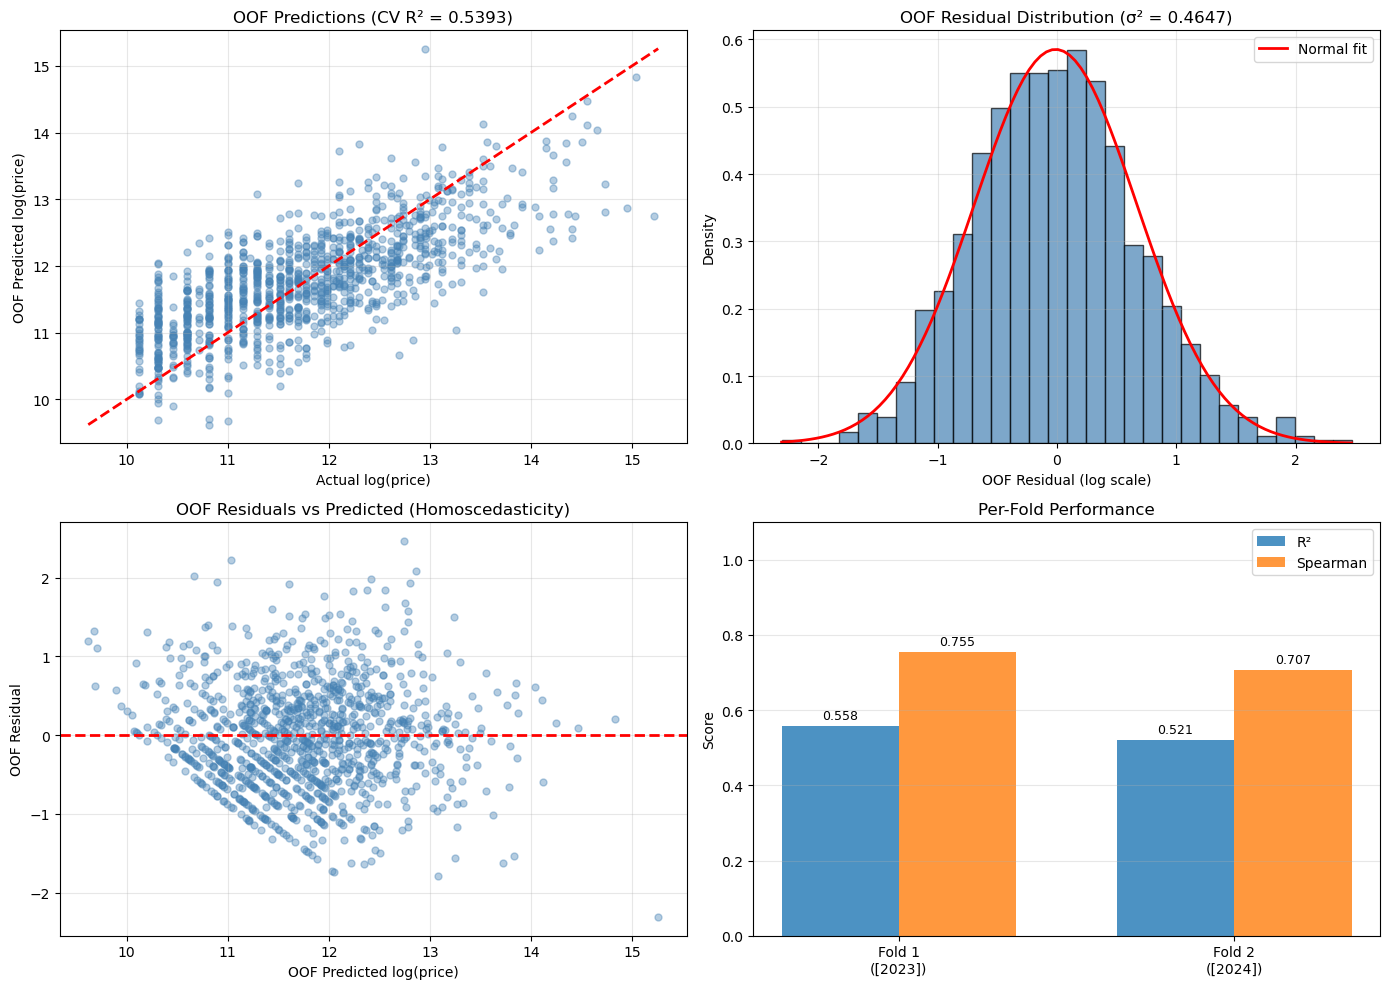


✓ Saved: lr_cv_oof_analysis.png

UPDATING SIGMA² FOR DOWNSTREAM CELLS
  sigma2 = 0.4647  (OOF estimate)
  exp(sigma2/2) = 1.2616

  pred_train_price and pred_test_price updated with OOF σ²
  All downstream cells will use this corrected value

✓ Saved: lr_cv_metrics.xlsx
✓ Saved: lr_oof_predictions.xlsx

LINEAR REGRESSION CROSS-VALIDATION COMPLETE


In [55]:
# =========================================================
# LINEAR REGRESSION: CROSS-VALIDATED METRICS & OOF SIGMA²
# =========================================================
# Matches the GroupKFold(n_splits=2) approach used in
# XGBoost, Random Forest, and GAM for consistent comparison.
#
# Breeder encoding and imputation are redone inside each
# fold to prevent data leakage.
#
# Place this cell AFTER Cell 5 (Linear Regression Model)
# so that FEATURES, pred_train, pred_test, etc. exist.
# =========================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr
from scipy import stats as sp_stats

print("=" * 70)
print("LINEAR REGRESSION: CROSS-VALIDATED METRICS & OOF SIGMA²")
print("=" * 70)

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
N_SPLITS = 2  # 2 years → 2 folds (2023 vs 2024)
groups = df_train[col_year].values

cv = GroupKFold(n_splits=N_SPLITS)
folds = list(cv.split(df_train, y_train, groups=groups))

print(f"\n[CV SETUP]")
print(f"  Strategy:  GroupKFold (group = Year)")
print(f"  Folds:     {N_SPLITS}")
for fold_idx, (train_pos, val_pos) in enumerate(folds):
    fold_years_train = df_train.iloc[train_pos][col_year].unique()
    fold_years_val = df_train.iloc[val_pos][col_year].unique()
    print(f"  Fold {fold_idx+1}:   Train on {sorted(fold_years_train)} ({len(train_pos)} rows) "
          f"→ Predict {sorted(fold_years_val)} ({len(val_pos)} rows)")


# ---------------------------------------------------------
# Helper: Breeder LOO target encoding (per fold)
# ---------------------------------------------------------
def encode_breeder_fold(df_fold_train, df_fold_val, col_breeder, target):
    """
    Breeder target encoding with LOO for fold-train,
    standard smoothed encoding for fold-val.
    """
    global_mean = df_fold_train[target].mean()

    stats = df_fold_train.groupby(col_breeder)[target].agg(["sum", "count", "std"])
    stats.columns = ["breeder_sum", "n", "breeder_std"]
    stats["breeder_mean"] = stats["breeder_sum"] / stats["n"]

    global_var = df_fold_train[target].var()
    within_var = stats["breeder_std"].mean() ** 2
    m = global_var / within_var if within_var > 0 else 5

    # FOLD TRAIN: Leave-One-Out
    train_sum = df_fold_train[col_breeder].map(stats["breeder_sum"])
    train_n = df_fold_train[col_breeder].map(stats["n"])
    loo_mean = (train_sum - df_fold_train[target]) / (train_n - 1)
    loo_mean = loo_mean.fillna(global_mean)
    loo_n = (train_n - 1).clip(lower=0)
    fold_train_encoded = (loo_n * loo_mean + m * global_mean) / (loo_n + m)
    fold_train_encoded = fold_train_encoded.fillna(global_mean)

    # FOLD VAL: Standard smoothed
    val_n = df_fold_val[col_breeder].map(stats["n"]).fillna(0)
    val_mean = df_fold_val[col_breeder].map(stats["breeder_mean"]).fillna(global_mean)
    fold_val_encoded = (val_n * val_mean + m * global_mean) / (val_n + m)
    fold_val_encoded = fold_val_encoded.fillna(global_mean)

    return fold_train_encoded, fold_val_encoded


# ---------------------------------------------------------
# Helper: Smart imputation (per fold)
# ---------------------------------------------------------
def impute_fold(X_fold_train, X_fold_val, zero_cols, median_cols):
    """Zero-impute and median-impute using fold-train stats only."""
    X_tr = X_fold_train.copy()
    X_va = X_fold_val.copy()

    for col in zero_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].fillna(0)
            X_va[col] = X_va[col].fillna(0)

    for col in median_cols:
        if col and col in X_tr.columns:
            if X_tr[col].isna().sum() > 0:
                med = X_tr[col].median()
                X_tr[col] = X_tr[col].fillna(med)
                X_va[col] = X_va[col].fillna(med)

    return X_tr, X_va


# ---------------------------------------------------------
# Imputation column lists (same as Cell 4)
# ---------------------------------------------------------
zero_impute_cols = [
    "SiblingEarningsPerHorse",
    "SiblingEarningsPerStart",
    "SiblingWinPct",
    "dam_time_inverse",
    "DamEarningsPerStart",
    "DamWinPct",
]

median_impute_cols = [
    "GranddamEarningsPerHorse",
    "GranddamWinPct",
    "GD_Dam_EarningsPerHorse",
    "GD_Dam_WinPct",
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    "XRAY_RISK_SCORE",
]


# =========================================================
# CROSS-VALIDATION LOOP
# =========================================================

oof_predictions = np.full(len(df_train), np.nan)
fold_metrics = []

for fold_idx, (train_pos, val_pos) in enumerate(folds):
    print(f"\n{'─' * 70}")
    print(f"FOLD {fold_idx + 1}/{N_SPLITS}")
    print(f"{'─' * 70}")

    # --- Split data ---
    df_f_train = df_train.iloc[train_pos].copy()
    df_f_val = df_train.iloc[val_pos].copy()
    y_f_train = y_train.iloc[train_pos].copy()
    y_f_val = y_train.iloc[val_pos].copy()

    # --- 1. Breeder encoding (per fold) ---
    df_f_train["Breeder_Encoded"], df_f_val["Breeder_Encoded"] = encode_breeder_fold(
        df_f_train, df_f_val, col_breeder, "log_price"
    )

    # --- 2. Build feature matrices ---
    X_f_train_raw = df_f_train[FEATURES].copy()
    X_f_val_raw = df_f_val[FEATURES].copy()

    X_f_train_raw = X_f_train_raw.replace([np.inf, -np.inf], np.nan)
    X_f_val_raw = X_f_val_raw.replace([np.inf, -np.inf], np.nan)

    # --- 3. Imputation (per fold) ---
    X_f_train_imp, X_f_val_imp = impute_fold(
        X_f_train_raw, X_f_val_raw, zero_impute_cols, median_impute_cols
    )

    # --- 4. Verify no NaNs ---
    n_nan_train = X_f_train_imp.isna().sum().sum()
    n_nan_val = X_f_val_imp.isna().sum().sum()
    if n_nan_train > 0 or n_nan_val > 0:
        print(f"  ⚠ Remaining NaNs: train={n_nan_train}, val={n_nan_val}")
        X_f_train_imp = X_f_train_imp.fillna(0)
        X_f_val_imp = X_f_val_imp.fillna(0)

    # --- 5. Fit Linear Regression ---
    fold_model = LinearRegression()
    fold_model.fit(X_f_train_imp, y_f_train)

    # --- 6. Predict on validation fold ---
    fold_pred = fold_model.predict(X_f_val_imp)
    oof_predictions[val_pos] = fold_pred

    # --- 7. Fold metrics (log scale) ---
    fold_r2 = r2_score(y_f_val, fold_pred)
    fold_rmse = np.sqrt(mean_squared_error(y_f_val, fold_pred))
    fold_mae = mean_absolute_error(y_f_val, fold_pred)
    fold_mape = np.mean(np.abs((y_f_val.values - fold_pred) / y_f_val.values)) * 100
    fold_mdape = np.median(np.abs((y_f_val.values - fold_pred) / y_f_val.values)) * 100
    fold_spearman, _ = spearmanr(y_f_val.values, fold_pred)

    fold_years_val = sorted(df_f_val[col_year].unique())
    fold_metrics.append({
        "Fold": fold_idx + 1,
        "Val_Years": str(fold_years_val),
        "N_train": len(train_pos),
        "N_val": len(val_pos),
        "R²": fold_r2,
        "RMSE": fold_rmse,
        "MAE": fold_mae,
        "MAPE": fold_mape,
        "MdAPE": fold_mdape,
        "Spearman": fold_spearman,
    })

    print(f"\n  [FOLD {fold_idx+1} RESULTS — Log Scale]")
    print(f"    R²:       {fold_r2:.4f}")
    print(f"    RMSE:     {fold_rmse:.4f}")
    print(f"    MAE:      {fold_mae:.4f}")
    print(f"    MAPE:     {fold_mape:.2f}%")
    print(f"    MdAPE:    {fold_mdape:.2f}%")
    print(f"    Spearman: {fold_spearman:.4f}")


# =========================================================
# AGGREGATE CV RESULTS
# =========================================================

print(f"\n{'=' * 70}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'=' * 70}")

metrics_df = pd.DataFrame(fold_metrics)

print(f"\n[PER-FOLD RESULTS]")
print(metrics_df.to_string(index=False, float_format="%.4f"))

weights = metrics_df["N_val"].values

print(f"\n[AGGREGATED CV METRICS — Log Scale]")
print(f"  {'Metric':<12} {'Mean':>10} {'Std':>10} {'Weighted Mean':>15}")
print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*15}")

for metric in ["R²", "RMSE", "MAE", "MAPE", "MdAPE", "Spearman"]:
    vals = metrics_df[metric].values
    m = np.mean(vals)
    s = np.std(vals)
    wm = np.average(vals, weights=weights)
    print(f"  {metric:<12} {m:>10.4f} {s:>10.4f} {wm:>15.4f}")


# =========================================================
# OUT-OF-FOLD SIGMA² ESTIMATION
# =========================================================

print(f"\n{'=' * 70}")
print("OUT-OF-FOLD SIGMA² ESTIMATION")
print(f"{'=' * 70}")

assert not np.any(np.isnan(oof_predictions)), "Some OOF predictions are NaN!"

oof_residuals = y_train.values - oof_predictions
sigma2_oof = np.var(oof_residuals)
sigma2_train = np.var(y_train.values - pred_train)  # from Cell 5

print(f"\n[SIGMA² COMPARISON]")
print(f"  {'Method':<25} {'σ²':>10} {'exp(σ²/2)':>12} {'Note'}")
print(f"  {'-'*25} {'-'*10} {'-'*12} {'-'*30}")
print(f"  {'Training (in-sample)':<25} {sigma2_train:>10.4f} {np.exp(sigma2_train/2):>12.4f} Optimistic (model sees data)")
print(f"  {'OOF (out-of-fold)':<25} {sigma2_oof:>10.4f} {np.exp(sigma2_oof/2):>12.4f} Realistic (unseen data)")

ratio = sigma2_oof / sigma2_train if sigma2_train > 0 else float("inf")
print(f"\n  OOF σ² is {ratio:.2f}x the training σ²")

if ratio > 2.0:
    print(f"  ⚠ Large gap — model variance is underestimated in-sample")
elif ratio > 1.5:
    print(f"  ~ Moderate gap — OOF estimate is meaningfully higher")
else:
    print(f"  ✓ Small gap — training estimate is reasonable")

print(f"\n  → Using OOF σ² = {sigma2_oof:.4f} for price-scale back-transformation")


# =========================================================
# RECALCULATE PRICE-SCALE METRICS WITH OOF SIGMA²
# =========================================================

print(f"\n{'=' * 70}")
print("PRICE-SCALE METRICS (using OOF σ²)")
print(f"{'=' * 70}")

pred_train_price_oof = np.exp(pred_train + sigma2_oof / 2)
pred_test_price_oof = np.exp(pred_test + sigma2_oof / 2)

print(f"\n[CORRECTION COMPARISON]")
print(f"  Training σ² correction: exp({sigma2_train:.4f}/2) = {np.exp(sigma2_train/2):.4f}")
print(f"  OOF σ²  correction:    exp({sigma2_oof:.4f}/2) = {np.exp(sigma2_oof/2):.4f}")

y_test_price = np.exp(y_test.values)

test_r2_price_oof = r2_score(y_test_price, pred_test_price_oof)
rmse_price_oof = np.sqrt(mean_squared_error(y_test_price, pred_test_price_oof))
mae_price_oof = mean_absolute_error(y_test_price, pred_test_price_oof)
mean_error_oof = np.mean(pred_test_price_oof - y_test_price)
median_error_oof = np.median(pred_test_price_oof - y_test_price)
mape_price_oof = np.mean(np.abs((y_test_price - pred_test_price_oof) / y_test_price)) * 100
mdape_price_oof = np.median(np.abs((y_test_price - pred_test_price_oof) / y_test_price)) * 100

print(f"\n[TEST SET — PRICE SCALE (NOK)]")
print(f"  {'Metric':<15} {'Train σ²':>15} {'OOF σ²':>15} {'Δ':>12}")
print(f"  {'-'*15} {'-'*15} {'-'*15} {'-'*12}")
print(f"  {'R²':<15} {test_r2_price:>15.4f} {test_r2_price_oof:>15.4f} {test_r2_price_oof - test_r2_price:>+12.4f}")
print(f"  {'RMSE':<15} {rmse_price:>15,.0f} {rmse_price_oof:>15,.0f} {rmse_price_oof - rmse_price:>+12,.0f}")
print(f"  {'MAE':<15} {mae_price:>15,.0f} {mae_price_oof:>15,.0f} {mae_price_oof - mae_price:>+12,.0f}")
print(f"  {'Mean Error':<15} {mean_error:>+15,.0f} {mean_error_oof:>+15,.0f} {mean_error_oof - mean_error:>+12,.0f}")
print(f"  {'MAPE':<15} {mape_price:>14.1f}% {mape_price_oof:>14.1f}% {mape_price_oof - mape_price:>+11.1f}%")
print(f"  {'MdAPE':<15} {mdape_price:>14.1f}% {mdape_price_oof:>14.1f}% {mdape_price_oof - mdape_price:>+11.1f}%")


# =========================================================
# OOF RESIDUAL DIAGNOSTICS
# =========================================================

print(f"\n{'=' * 70}")
print("OOF RESIDUAL DIAGNOSTICS")
print(f"{'=' * 70}")

print(f"\n[OOF RESIDUAL STATISTICS — Log Scale]")
print(f"  Mean:     {np.mean(oof_residuals):.4f}")
print(f"  Std:      {np.std(oof_residuals):.4f}")
print(f"  Skewness: {sp_stats.skew(oof_residuals):.4f}")
print(f"  Kurtosis: {sp_stats.kurtosis(oof_residuals):.4f}")

stat_sw, p_sw = sp_stats.shapiro(oof_residuals)
print(f"\n  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} "
      f"→ {'Normal ✓' if p_sw > 0.05 else 'Not Normal ✗'}")

train_residuals = y_train.values - pred_train
print(f"\n[OOF vs TRAINING RESIDUAL COMPARISON]")
print(f"  {'Statistic':<15} {'Training':>12} {'OOF':>12}")
print(f"  {'-'*15} {'-'*12} {'-'*12}")
print(f"  {'Std':<15} {np.std(train_residuals):>12.4f} {np.std(oof_residuals):>12.4f}")
print(f"  {'Skewness':<15} {sp_stats.skew(train_residuals):>12.4f} {sp_stats.skew(oof_residuals):>12.4f}")
print(f"  {'Kurtosis':<15} {sp_stats.kurtosis(train_residuals):>12.4f} {sp_stats.kurtosis(oof_residuals):>12.4f}")


# =========================================================
# VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: OOF Predicted vs Actual
ax1 = axes[0, 0]
ax1.scatter(y_train.values, oof_predictions, alpha=0.4, s=25, c="steelblue")
lims = [min(y_train.min(), oof_predictions.min()),
        max(y_train.max(), oof_predictions.max())]
ax1.plot(lims, lims, "r--", lw=2)
ax1.set_xlabel("Actual log(price)")
ax1.set_ylabel("OOF Predicted log(price)")
ax1.set_title(f"OOF Predictions (CV R² = {np.mean(metrics_df['R²']):.4f})")
ax1.grid(True, alpha=0.3)

# Plot 2: OOF Residual histogram
ax2 = axes[0, 1]
ax2.hist(oof_residuals, bins=30, density=True, alpha=0.7, color="steelblue", edgecolor="black")
x_grid = np.linspace(oof_residuals.min(), oof_residuals.max(), 100)
ax2.plot(x_grid, sp_stats.norm.pdf(x_grid, np.mean(oof_residuals), np.std(oof_residuals)),
         "r-", lw=2, label="Normal fit")
ax2.set_xlabel("OOF Residual (log scale)")
ax2.set_ylabel("Density")
ax2.set_title(f"OOF Residual Distribution (σ² = {sigma2_oof:.4f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: OOF Residuals vs Predicted
ax3 = axes[1, 0]
ax3.scatter(oof_predictions, oof_residuals, alpha=0.4, s=25, c="steelblue")
ax3.axhline(y=0, color="r", linestyle="--", lw=2)
ax3.set_xlabel("OOF Predicted log(price)")
ax3.set_ylabel("OOF Residual")
ax3.set_title("OOF Residuals vs Predicted (Homoscedasticity)")
ax3.grid(True, alpha=0.3)

# Plot 4: Fold comparison
ax4 = axes[1, 1]
fold_labels = [f"Fold {r['Fold']}\n({r['Val_Years']})" for _, r in metrics_df.iterrows()]
metric_names = ["R²", "Spearman"]
x = np.arange(len(fold_labels))
width = 0.35
for j, metric in enumerate(metric_names):
    offset = (j - 0.5) * width
    vals = metrics_df[metric].values
    bars = ax4.bar(x + offset, vals, width, label=metric, alpha=0.8)
    for bar, val in zip(bars, vals):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax4.set_xticks(x)
ax4.set_xticklabels(fold_labels)
ax4.set_ylabel("Score")
ax4.set_title("Per-Fold Performance")
ax4.legend()
ax4.grid(True, alpha=0.3, axis="y")
ax4.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("lr_cv_oof_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Saved: lr_cv_oof_analysis.png")


# =========================================================
# UPDATE SIGMA² AND PRICE PREDICTIONS
# =========================================================

print(f"\n{'=' * 70}")
print("UPDATING SIGMA² FOR DOWNSTREAM CELLS")
print(f"{'=' * 70}")

sigma2 = sigma2_oof
pred_train_price = np.exp(pred_train + sigma2 / 2)
pred_test_price = np.exp(pred_test + sigma2 / 2)

print(f"  sigma2 = {sigma2:.4f}  (OOF estimate)")
print(f"  exp(sigma2/2) = {np.exp(sigma2/2):.4f}")
print(f"\n  pred_train_price and pred_test_price updated with OOF σ²")
print(f"  All downstream cells will use this corrected value")


# =========================================================
# EXPORT
# =========================================================

cv_export = metrics_df.copy()
cv_export.loc["Mean"] = cv_export.select_dtypes(include=[np.number]).mean()
cv_export.loc["Std"] = metrics_df.select_dtypes(include=[np.number]).std()
cv_export.to_excel("lr_cv_metrics.xlsx", index=False)
print(f"\n✓ Saved: lr_cv_metrics.xlsx")

oof_export = pd.DataFrame({
    "log_price_actual": y_train.values,
    "log_price_oof_pred": oof_predictions,
    "oof_residual": oof_residuals,
    "year": df_train[col_year].values,
}, index=df_train.index)
oof_export.to_excel("lr_oof_predictions.xlsx")
print(f"✓ Saved: lr_oof_predictions.xlsx")

print(f"\n{'=' * 70}")
print("LINEAR REGRESSION CROSS-VALIDATION COMPLETE")
print(f"{'=' * 70}")


In [56]:
# =========================================================
# EXPORT: TRAINING / OOF / TEST PERFORMANCE TABLE (LOG SCALE)
# =========================================================
# Requires: pred_train, pred_test, y_train, y_test,
#           oof_predictions (from CV cell)
# =========================================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from docx import Document
from docx.shared import Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import nsdecls
from docx.oxml import parse_xml
import numpy as np

print("=" * 70)
print("TRAINING / OOF / TEST PERFORMANCE (LOG SCALE)")
print("=" * 70)

# ---------------------------------------------------------
# 1. Compute metrics for all three sets
# ---------------------------------------------------------

# Training
train_r2 = r2_score(y_train, pred_train)
train_mae = mean_absolute_error(y_train, pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))

# OOF
oof_r2 = r2_score(y_train.values, oof_predictions)
oof_mae = mean_absolute_error(y_train.values, oof_predictions)
oof_rmse = np.sqrt(mean_squared_error(y_train.values, oof_predictions))

# Test
test_r2 = r2_score(y_test, pred_test)
test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))

# Print summary
print(f"\n{'Metric':<10} {'Training':>12} {'OOF':>12} {'Test':>12}")
print("-" * 50)
print(f"{'R²':<10} {train_r2:>12.4f} {oof_r2:>12.4f} {test_r2:>12.4f}")
print(f"{'MAE':<10} {train_mae:>12.4f} {oof_mae:>12.4f} {test_mae:>12.4f}")
print(f"{'RMSE':<10} {train_rmse:>12.4f} {oof_rmse:>12.4f} {test_rmse:>12.4f}")

print(f"\n[GENERALIZATION GAPS]")
print(f"  Train → OOF:   R² drops {train_r2 - oof_r2:.4f} ({(train_r2 - oof_r2)/train_r2*100:.1f}%)")
print(f"  OOF → Test:    R² drops {oof_r2 - test_r2:.4f} ({(oof_r2 - test_r2)/oof_r2*100:.1f}%)")
print(f"  Train → Test:  R² drops {train_r2 - test_r2:.4f} ({(train_r2 - test_r2)/train_r2*100:.1f}%)")

# ---------------------------------------------------------
# 2. Export to Word
# ---------------------------------------------------------

doc = Document()
style = doc.styles["Normal"]
style.font.name = "Times New Roman"
style.font.size = Pt(11)

# Caption
caption = doc.add_paragraph()
caption.alignment = WD_ALIGN_PARAGRAPH.LEFT
run = caption.add_run(
    "Table X: Training, Out-of-Fold (OOF) and Test Performance "
    "for selected metrics on log scale"
)
run.italic = True
run.font.size = Pt(10)
run.font.name = "Times New Roman"

# Table
table = doc.add_table(rows=4, cols=4)
table.alignment = WD_TABLE_ALIGNMENT.CENTER
table.style = "Table Grid"

# Header row
headers = ["", "Training", "OOF", "Test"]
for j, h in enumerate(headers):
    cell = table.rows[0].cells[j]
    cell.text = h
    run = cell.paragraphs[0].runs[0]
    run.bold = True
    run.font.size = Pt(10)
    run.font.name = "Times New Roman"
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
    shading = parse_xml(f'<w:shd {nsdecls("w")} w:fill="D9E2F3"/>')
    cell._tc.get_or_add_tcPr().append(shading)

# Data rows
data = [
    ("R²",   train_r2,   oof_r2,   test_r2),
    ("MAE",  train_mae,  oof_mae,  test_mae),
    ("RMSE", train_rmse, oof_rmse, test_rmse),
]

for i, (label, v_train, v_oof, v_test) in enumerate(data):
    r = i + 1
    # Metric name
    cell = table.rows[r].cells[0]
    cell.text = label
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.LEFT
    for run in cell.paragraphs[0].runs:
        run.bold = True
        run.font.size = Pt(10)
        run.font.name = "Times New Roman"

    # Values
    for j, val in enumerate([v_train, v_oof, v_test]):
        cell = table.rows[r].cells[j + 1]
        cell.text = f"{val:.4f}"
        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        for run in cell.paragraphs[0].runs:
            run.font.size = Pt(10)
            run.font.name = "Times New Roman"

# Column widths
col_widths = [Cm(3.0), Cm(3.0), Cm(3.0), Cm(3.0)]
for row_obj in table.rows:
    for j, w in enumerate(col_widths):
        row_obj.cells[j].width = w

filename = "LR_Training_OOF_Test_Table.docx"
doc.save(filename)
print(f"\n✓ Saved: {filename}")

TRAINING / OOF / TEST PERFORMANCE (LOG SCALE)

Metric         Training          OOF         Test
--------------------------------------------------
R²               0.5937       0.5427       0.4036
MAE              0.5142       0.5438       0.6324
RMSE             0.6426       0.6818       0.7699

[GENERALIZATION GAPS]
  Train → OOF:   R² drops 0.0510 (8.6%)
  OOF → Test:    R² drops 0.1391 (25.6%)
  Train → Test:  R² drops 0.1901 (32.0%)


PermissionError: [Errno 13] Permission denied: 'LR_Training_OOF_Test_Table.docx'

In [ ]:
# =========================================================
# BIAS CORRECTION METHOD COMPARISON
# =========================================================
# Requires: pred_test, y_test, y_train, pred_train, sigma2_oof,
#           oof_predictions (from CV cell)
# =========================================================

from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

print("=" * 70)
print("BIAS CORRECTION METHOD COMPARISON")
print("=" * 70)

y_test_price = np.exp(y_test)
y_train_price = np.exp(y_train)

# ---------------------------------------------------------
# 1. Compute all sigma estimates
# ---------------------------------------------------------

sigma2_train = np.var(y_train - pred_train)
# sigma2_oof already computed in CV cell

# Smearing factors (Duan, 1983)
insample_residuals = y_train - pred_train
oof_residuals = y_train.values - oof_predictions
smear_insample = np.mean(np.exp(insample_residuals))
smear_oof = np.mean(np.exp(oof_residuals))

print(f"\n[SIGMA ESTIMATES]")
print(f"  Training σ²:       {sigma2_train:.4f}  →  correction: {np.exp(sigma2_train/2):.4f}")
print(f"  OOF σ²:            {sigma2_oof:.4f}  →  correction: {np.exp(sigma2_oof/2):.4f}")
print(f"  Duan (in-sample):  smear = {smear_insample:.4f}")
print(f"  Duan (OOF):        smear = {smear_oof:.4f}")

# ---------------------------------------------------------
# 2. Generate price predictions with each method
# ---------------------------------------------------------

corrections = {
    "No correction (median)":  np.exp(pred_test),
#    "Training σ²/2":           np.exp(pred_test + sigma2_train / 2),
    "OOF σ²/2":                np.exp(pred_test + sigma2_oof / 2),
#    "Duan (in-sample)":        np.exp(pred_test) * smear_insample,
    "Duan (OOF)":              np.exp(pred_test) * smear_oof,
}

# ---------------------------------------------------------
# 3. Compare all methods
# ---------------------------------------------------------

print(f"\n[METHOD COMPARISON - TEST SET]")
print(f"{'Method':<25} {'R²':>8} {'MAE':>10} {'MdAPE':>8} {'Mean Err':>12} {'Median Err':>12}")
print("-" * 80)

results = []
for name, pred_price in corrections.items():
    r2 = r2_score(y_test_price, pred_price)
    mae = mean_absolute_error(y_test_price, pred_price)
    mdape = np.median(np.abs((y_test_price - pred_price) / y_test_price)) * 100
    mean_err = np.mean(pred_price - y_test_price)
    median_err = np.median(pred_price - y_test_price)
    results.append({"name": name, "r2": r2, "mae": mae, "mdape": mdape,
                     "mean_err": mean_err, "median_err": median_err, "pred": pred_price})
    print(f"{name:<25} {r2:>8.4f} {mae:>10,.0f} {mdape:>7.1f}% {mean_err:>+12,.0f} {median_err:>+12,.0f}")

# ---------------------------------------------------------
# 4. Identify best method by each criterion
# ---------------------------------------------------------

print(f"\n[BEST METHOD BY CRITERION]")
best_r2 = max(results, key=lambda x: x["r2"])
best_mae = min(results, key=lambda x: x["mae"])
best_mdape = min(results, key=lambda x: x["mdape"])
best_mean = min(results, key=lambda x: abs(x["mean_err"]))
best_median = min(results, key=lambda x: abs(x["median_err"]))

print(f"  Best R²:          {best_r2['name']} ({best_r2['r2']:.4f})")
print(f"  Best MAE:         {best_mae['name']} ({best_mae['mae']:,.0f})")
print(f"  Best MdAPE:       {best_mdape['name']} ({best_mdape['mdape']:.1f}%)")
print(f"  Best Mean Error:  {best_mean['name']} ({best_mean['mean_err']:+,.0f})")
print(f"  Best Median Error:{best_median['name']} ({best_median['median_err']:+,.0f})")

# ---------------------------------------------------------
# 5. Apply best method (by R²) to downstream variables
# ---------------------------------------------------------

best = best_r2  # Change to best_median or best_mdape if preferred
print(f"\n→ Selected: {best['name']} (best R²)")

pred_test_price = best["pred"]

# Also recompute train prices with same method
if "No correction" in best["name"]:
    pred_train_price = np.exp(pred_train)
    correction_method = "No correction (median)"
elif "OOF" in best["name"] and "Duan" in best["name"]:
    pred_train_price = np.exp(pred_train) * smear_oof
    correction_method = f"Duan OOF (smear={smear_oof:.4f})"
elif "Duan" in best["name"]:
    pred_train_price = np.exp(pred_train) * smear_insample
    correction_method = f"Duan in-sample (smear={smear_insample:.4f})"
elif "OOF" in best["name"]:
    pred_train_price = np.exp(pred_train + sigma2_oof / 2)
    correction_method = f"OOF σ²/2 (σ²={sigma2_oof:.4f}, factor={np.exp(sigma2_oof/2):.4f})"
elif "Training" in best["name"]:
    pred_train_price = np.exp(pred_train + sigma2_train / 2)
    correction_method = f"Training σ²/2 (σ²={sigma2_train:.4f}, factor={np.exp(sigma2_train/2):.4f})"

print(f"  Applied: {correction_method}")
print(f"  pred_train_price and pred_test_price updated for downstream cells")

mape_price = np.mean(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100
mdape_price = np.median(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100

print(f"  MAPE:          {mape_price:.1f}%")
print(f"  MdAPE:         {mdape_price:.1f}%")





In [ ]:
# =========================================================
# COEFFICIENT ANALYSIS
# =========================================================

print("="*70)
print("COEFFICIENT ANALYSIS")
print("="*70)

# ---------------------------------------------------------
# Raw coefficients
# ---------------------------------------------------------
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n[INTERCEPT]")
print(f"  {model.intercept_:.4f}")

print(f"\n[COEFFICIENTS (sorted by absolute value)]")
#print(coef_df.to_string(index=False):.3f})
print(coef_df.to_string(index=False, float_format='{:.3f}'.format))

# ---------------------------------------------------------
# Standardized coefficients (for fair comparison)
# ---------------------------------------------------------
print(f"\n[STANDARDIZED COEFFICIENTS]")
print("  (Shows relative importance - accounts for different scales)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

std_coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Std_Coefficient': model_scaled.coef_,
    'Abs_Std_Coef': np.abs(model_scaled.coef_)
}).sort_values('Abs_Std_Coef', ascending=False)

print(std_coef_df[['Feature', 'Std_Coefficient']].head(15).to_string(index=False))

# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------
print(f"\n[INTERPRETATION]")
print("  Positive coefficient: Higher value → Higher price")
print("  Negative coefficient: Higher value → Lower price")
print("  Standardized: 1 std increase in X → β std increase in log(price)")

# Top positive
top_pos = std_coef_df[std_coef_df['Std_Coefficient'] > 0].head(5)
print(f"\n  TOP POSITIVE EFFECTS:")
for _, row in top_pos.iterrows():
    print(f"    {row['Feature']}: +{row['Std_Coefficient']:.3f}")

# Top negative
top_neg = std_coef_df[std_coef_df['Std_Coefficient'] < 0].head(5)
print(f"\n  TOP NEGATIVE EFFECTS:")
for _, row in top_neg.iterrows():
    print(f"    {row['Feature']}: {row['Std_Coefficient']:.3f}")

# ---------------------------------------------------------
# Plot coefficients
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Raw coefficients (top 20)
ax1 = axes[0]
top_20 = coef_df.head(20)
colors = ['green' if c > 0 else 'red' for c in top_20['Coefficient']]
ax1.barh(range(len(top_20)), top_20['Coefficient'].values[::-1], color=colors[::-1])
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['Feature'].values[::-1])
ax1.set_xlabel('Coefficient')
ax1.set_title('Raw Coefficients (Top 20)')
ax1.axvline(x=0, color='black', linewidth=0.5)

# Standardized coefficients (top 20)
ax2 = axes[1]
top_20_std = std_coef_df.head(20)
colors = ['green' if c > 0 else 'red' for c in top_20_std['Std_Coefficient']]
ax2.barh(range(len(top_20_std)), top_20_std['Std_Coefficient'].values[::-1], color=colors[::-1])
ax2.set_yticks(range(len(top_20_std)))
ax2.set_yticklabels(top_20_std['Feature'].values[::-1])
ax2.set_xlabel('Standardized Coefficient')
ax2.set_title('Standardized Coefficients (Top 20)')
ax2.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('LR_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =========================================================
# OLS REGRESSION SUMMARY
# =========================================================

print("="*70)
print("OLS REGRESSION SUMMARY")
print("="*70)

# Debug: Check import
try:
    import statsmodels.api as sm
    print("✓ statsmodels imported successfully")
except Exception as e:
    print(f"✗ Import error: {type(e).__name__}: {e}")
    sm = None

if sm is not None:
    # Add constant for intercept
    X_train_sm = sm.add_constant(X_train)
    
    # Fit OLS model
    ols_model = sm.OLS(y_train, X_train_sm).fit()
    
    # Print summary
    print(ols_model.summary())

In [73]:
# =========================================================
# EXPORT OLS SUMMARY TABLE TO WORD
# =========================================================
# Place after Cell 7 (OLS Regression Summary)
# Requires: ols_model, FEATURES, model (from earlier cells)
# pip install python-docx
# =========================================================

from docx import Document
from docx.shared import Pt, Inches, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
import numpy as np

print("=" * 70)
print("EXPORT OLS SUMMARY TO WORD")
print("=" * 70)

# ---------------------------------------------------------
# 1. Extract OLS results into a DataFrame
# ---------------------------------------------------------

ols_summary = pd.DataFrame({
    "Variable": ols_model.params.index,
    "Coef": ols_model.params.values,
    "Std Err": ols_model.bse.values,
    "t": ols_model.tvalues.values,
    "P>|t|": ols_model.pvalues.values,
    "CI Lower": ols_model.conf_int()[0].values,
    "CI Upper": ols_model.conf_int()[1].values,
})

# Add significance stars
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "."
    return ""

ols_summary["Sig"] = ols_summary["P>|t|"].apply(sig_stars)

# Rename 'const' to 'Intercept'
ols_summary["Variable"] = ols_summary["Variable"].replace("const", "Intercept")

# ---------------------------------------------------------
# 1b. Compute standardized coefficients
# ---------------------------------------------------------
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

scaler = StandardScaler()
X_train_std = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_train_std_sm = sm.add_constant(X_train_std)
ols_std = sm.OLS(y_train, X_train_std_sm).fit()

# Map standardized coefficients to summary (intercept gets NaN)
std_coef_map = {var: ols_std.params[var] for var in ols_std.params.index if var != "const"}
ols_summary["Std Coef"] = ols_summary["Variable"].map(std_coef_map)

# Sort by absolute standardized coefficient (most important first)
ols_summary = ols_summary.sort_values("Std Coef", key=lambda x: x.abs(), ascending=False, na_position="first").reset_index(drop=True)

print(f"  Extracted {len(ols_summary)} coefficients from OLS model")
print(f"  R² = {ols_model.rsquared:.4f}, Adj. R² = {ols_model.rsquared_adj:.4f}")
print(f"  F-statistic = {ols_model.fvalue:.2f}, p = {ols_model.f_pvalue:.4e}")

# ---------------------------------------------------------
# 2. Create Word document
# ---------------------------------------------------------

doc = Document()

# --- Document styles ---
style = doc.styles["Normal"]
style.font.name = "Times New Roman"
style.font.size = Pt(11)
style.paragraph_format.space_after = Pt(2)

# --- Title ---
title = doc.add_heading("OLS Regression Results", level=2)
title.alignment = WD_ALIGN_PARAGRAPH.LEFT

# --- Model summary paragraph ---
summary_text = (
    f"Dependent variable: log(price). "
    f"N = {int(ols_model.nobs):,}. "
    f"R\u00b2 = {ols_model.rsquared:.4f}. "
    f"Adjusted R\u00b2 = {ols_model.rsquared_adj:.4f}. "
    f"F({int(ols_model.df_model)}, {int(ols_model.df_resid)}) = {ols_model.fvalue:.2f} "
    f"(p < {max(ols_model.f_pvalue, 1e-10):.2e})."
)
p = doc.add_paragraph(summary_text)
p.style.font.size = Pt(10)

# --- Coefficient table ---
columns = ["Variable", "Coef", "Std Coef", "Std Err", "t", "P>|t|", "95% CI", ""]
n_rows = len(ols_summary) + 1  # +1 for header

table = doc.add_table(rows=n_rows, cols=len(columns))
table.alignment = WD_TABLE_ALIGNMENT.CENTER
table.style = "Table Grid"

# Header row
header_labels = ["Variable", "Coefficient", "Std. Coef.", "Std. Error", "t-value", "p-value", "95% CI", ""]
for j, label in enumerate(header_labels):
    cell = table.rows[0].cells[j]
    cell.text = label
    run = cell.paragraphs[0].runs[0]
    run.bold = True
    run.font.size = Pt(9)
    run.font.name = "Times New Roman"
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Helper: format coefficient with enough decimals
def fmt_coef(val):
    if pd.isna(val):
        return "\u2014"
    if val == 0:
        return "0.0000"
    if abs(val) < 0.0005:
        return f"{val:.6f}"
    return f"{val:.4f}"

# Data rows
for i, (_, row) in enumerate(ols_summary.iterrows()):
    r = i + 1  # offset by header

    # Variable name (left-aligned)
    cell = table.rows[r].cells[0]
    cell.text = str(row["Variable"])
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.LEFT
    for run in cell.paragraphs[0].runs:
        run.font.size = Pt(9)
        run.font.name = "Times New Roman"

    # Numeric columns (right-aligned)
    std_coef_str = fmt_coef(row["Std Coef"]) if pd.notna(row["Std Coef"]) else "\u2014"

    values = [
        fmt_coef(row['Coef']),
        std_coef_str,
        f"{row['Std Err']:.4f}",
        f"{row['t']:.3f}",
        f"{row['P>|t|']:.4f}" if row["P>|t|"] >= 0.0005 else "<0.001",
        f"[{row['CI Lower']:.4f}, {row['CI Upper']:.4f}]",
        row["Sig"],
    ]

    for j, val in enumerate(values):
        cell = table.rows[r].cells[j + 1]
        cell.text = val
        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT if j < 6 else WD_ALIGN_PARAGRAPH.LEFT
        for run in cell.paragraphs[0].runs:
            run.font.size = Pt(9)
            run.font.name = "Times New Roman"
            # Bold significant coefficients
            if j == 0 and abs(row["P>|t|"]) < 0.05:
                run.bold = True

# Adjust column widths
col_widths = [Cm(4.0), Cm(2.2), Cm(1.8), Cm(1.8), Cm(1.5), Cm(1.6), Cm(3.2), Cm(0.8)]
for row_obj in table.rows:
    for j, width in enumerate(col_widths):
        row_obj.cells[j].width = width

# --- Significance legend ---
legend = doc.add_paragraph()
legend.alignment = WD_ALIGN_PARAGRAPH.LEFT
run = legend.add_run("Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, . p < 0.10")
run.font.size = Pt(8)
run.font.name = "Times New Roman"
run.italic = True

# --- Model fit statistics ---
doc.add_paragraph("")
fit_table = doc.add_table(rows=6, cols=2)
fit_table.style = "Table Grid"
fit_table.alignment = WD_TABLE_ALIGNMENT.CENTER

fit_stats = [
    ("R\u00b2", f"{ols_model.rsquared:.4f}"),
    ("Adjusted R\u00b2", f"{ols_model.rsquared_adj:.4f}"),
    ("F-statistic", f"{ols_model.fvalue:.2f}"),
    ("AIC", f"{ols_model.aic:.1f}"),
    ("BIC", f"{ols_model.bic:.1f}"),
    ("Residual Std. Error", f"{np.sqrt(ols_model.mse_resid):.4f}"),
]

for i, (label, value) in enumerate(fit_stats):
    cell_l = fit_table.rows[i].cells[0]
    cell_l.text = label
    cell_l.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.LEFT
    for run in cell_l.paragraphs[0].runs:
        run.bold = True
        run.font.size = Pt(9)
        run.font.name = "Times New Roman"

    cell_r = fit_table.rows[i].cells[1]
    cell_r.text = value
    cell_r.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
    for run in cell_r.paragraphs[0].runs:
        run.font.size = Pt(9)
        run.font.name = "Times New Roman"

for row_obj in fit_table.rows:
    row_obj.cells[0].width = Cm(4.5)
    row_obj.cells[1].width = Cm(3.0)

# ---------------------------------------------------------
# 3. Save
# ---------------------------------------------------------

filename = "OLS_Summary_Table.docx"
doc.save(filename)
print(f"\n\u2713 Saved: {filename}")
print(f"  Contains:")
print(f"    - Model summary (N, R\u00b2, F-statistic)")
print(f"    - Coefficient table with Std. Coef, Std Err, t, p, 95% CI, significance stars")
print(f"    - Model fit statistics (R\u00b2, Adj R\u00b2, AIC, BIC)")


EXPORT OLS SUMMARY TO WORD
  Extracted 30 coefficients from OLS model
  R² = 0.5937, Adj. R² = 0.5828
  F-statistic = 54.32, p = 5.0517e-188

✓ Saved: OLS_Summary_Table.docx
  Contains:
    - Model summary (N, R², F-statistic)
    - Coefficient table with Std. Coef, Std Err, t, p, 95% CI, significance stars
    - Model fit statistics (R², Adj R², AIC, BIC)


In [ ]:
# =========================================================
# CORRECT VIF CALCULATION
# =========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

print("="*70)
print("CORRECT VIF CALCULATION")
print("="*70)

# METHOD 1: Center the data first (RECOMMENDED)
X_centered = X_train - X_train.mean()
X_centered_const = sm.add_constant(X_centered)

print("\n[VIF with CENTERED data]")
print(f"{'Feature':<35} {'VIF':>10}")
print("-" * 50)

for i, col in enumerate(X_centered_const.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_centered_const.values, i)
        status = '⚠️ High' if vif > 10 else '✓ OK'
        print(f"{col:<35} {vif:>10.2f}  {status}")

# METHOD 2: Standardize the data
X_standardized = (X_train - X_train.mean()) / X_train.std()
X_std_const = sm.add_constant(X_standardized)

print("\n[METHOD 2: VIF with STANDARDIZED data]")
print(f"{'Feature':<35} {'VIF':>10}")
print("-" * 50)

for i, col in enumerate(X_std_const.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_std_const.values, i)
        status = '⚠️ High' if vif > 10 else '✓ OK'
        print(f"{col:<35} {vif:>10.2f}  {status}")

# METHOD 3: Calculate VIF WITHOUT adding constant
# (VIF is about feature-feature collinearity, not feature-constant)
print("\n[METHOD 3: VIF WITHOUT constant term]")
print(f"{'Feature':<35} {'VIF':>10}")
print("-" * 50)

for i, col in enumerate(X_train.columns):
    vif = variance_inflation_factor(X_train.values, i)
    status = '⚠️ High' if vif > 10 else '✓ OK'
    print(f"{col:<35} {vif:>10.2f}  {status}")




In [ ]:
# =========================================================
# EXPORT VIF TABLE TO WORD
# =========================================================
# Place after the VIF calculation cell.
# Requires: X_train, FEATURES (from earlier cells)
# pip install python-docx
# =========================================================

from docx import Document
from docx.shared import Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import nsdecls
from docx.oxml import parse_xml
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

print("=" * 70)
print("EXPORT VIF TABLE TO WORD")
print("=" * 70)

# ---------------------------------------------------------
# 1. Calculate VIF (centered data)
# ---------------------------------------------------------

X_centered = X_train - X_train.mean()
X_centered_const = sm.add_constant(X_centered)

vif_data = []
for i, col in enumerate(X_centered_const.columns):
    if col != "const":
        vif = variance_inflation_factor(X_centered_const.values, i)
        if vif > 10:
            status = "High"
        elif vif > 5:
            status = "Moderate"
        else:
            status = "Low"
        vif_data.append({"Variable": col, "VIF": vif, "Status": status})

vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"  Calculated VIF for {len(vif_df)} features (centered data)")
print(f"  High (>10): {(vif_df['VIF'] > 10).sum()}")
print(f"  Moderate (5-10): {((vif_df['VIF'] > 5) & (vif_df['VIF'] <= 10)).sum()}")
print(f"  Low (<5): {(vif_df['VIF'] <= 5).sum()}")

# ---------------------------------------------------------
# 2. Create Word document
# ---------------------------------------------------------

doc = Document()

style = doc.styles["Normal"]
style.font.name = "Times New Roman"
style.font.size = Pt(11)

# Title
title = doc.add_heading("Variance Inflation Factors (VIF)", level=2)
title.alignment = WD_ALIGN_PARAGRAPH.LEFT

# Summary paragraph
n_high = (vif_df["VIF"] > 10).sum()
n_mod = ((vif_df["VIF"] > 5) & (vif_df["VIF"] <= 10)).sum()
summary = (
    f"VIF values computed on mean-centered predictors with intercept. "
    f"N = {len(X_train):,} observations, {len(vif_df)} predictors. "
)
if n_high > 0:
    summary += f"{n_high} variable(s) exceed the threshold of 10."
else:
    summary += "No variables exceed the threshold of 10."
p = doc.add_paragraph(summary)
p.style.font.size = Pt(10)

# Table
n_rows = len(vif_df) + 1
table = doc.add_table(rows=n_rows, cols=3)
table.alignment = WD_TABLE_ALIGNMENT.CENTER
table.style = "Table Grid"

# Header
header_labels = ["Variable", "VIF", "Collinearity"]
for j, label in enumerate(header_labels):
    cell = table.rows[0].cells[j]
    cell.text = label
    run = cell.paragraphs[0].runs[0]
    run.bold = True
    run.font.size = Pt(9)
    run.font.name = "Times New Roman"
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
    # Header shading
    shading = parse_xml(f'<w:shd {nsdecls("w")} w:fill="D9E2F3"/>')
    cell._tc.get_or_add_tcPr().append(shading)

# Data rows
for i, (_, row) in enumerate(vif_df.iterrows()):
    r = i + 1

    # Variable name
    cell = table.rows[r].cells[0]
    cell.text = str(row["Variable"])
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.LEFT
    for run in cell.paragraphs[0].runs:
        run.font.size = Pt(9)
        run.font.name = "Times New Roman"

    # VIF value
    cell = table.rows[r].cells[1]
    cell.text = f"{row['VIF']:.2f}"
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
    for run in cell.paragraphs[0].runs:
        run.font.size = Pt(9)
        run.font.name = "Times New Roman"
        if row["VIF"] > 10:
            run.bold = True

    # Status
    cell = table.rows[r].cells[2]
    cell.text = row["Status"]
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
    for run in cell.paragraphs[0].runs:
        run.font.size = Pt(9)
        run.font.name = "Times New Roman"

    # Row shading for high/moderate VIF
    if row["VIF"] > 10:
        for j in range(3):
            shading = parse_xml(f'<w:shd {nsdecls("w")} w:fill="FCE4EC"/>')
            table.rows[r].cells[j]._tc.get_or_add_tcPr().append(shading)
    elif row["VIF"] > 5:
        for j in range(3):
            shading = parse_xml(f'<w:shd {nsdecls("w")} w:fill="FFF8E1"/>')
            table.rows[r].cells[j]._tc.get_or_add_tcPr().append(shading)

# Column widths
col_widths = [Cm(7.0), Cm(2.5), Cm(3.0)]
for row_obj in table.rows:
    for j, width in enumerate(col_widths):
        row_obj.cells[j].width = width

# Legend
legend = doc.add_paragraph()
run = legend.add_run(
    "VIF < 5: Low collinearity. VIF 5\u201310: Moderate. VIF > 10: High (highlighted)."
)
run.font.size = Pt(8)
run.font.name = "Times New Roman"
run.italic = True

# ---------------------------------------------------------
# 3. Save
# ---------------------------------------------------------

filename = "VIF_Table.docx"
doc.save(filename)
print(f"\n\u2713 Saved: {filename}")


In [ ]:
# Are standard errors reasonable?
print(ols_model.summary().tables[1])
# Look at 'std err' column - if reasonable relative to coef, you're OK

In [ ]:
# =========================================================
# FOREST PLOT: STANDARDIZED COEFFICIENTS WITH 95% CI
# =========================================================
# Place after the OLS Summary / OLS Export cells.
# Requires: ols_model, X_train, y_train, FEATURES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("FOREST PLOT: STANDARDIZED OLS COEFFICIENTS")
print("=" * 70)

# ---------------------------------------------------------
# 1. Fit OLS on standardized features
# ---------------------------------------------------------

scaler = StandardScaler()
X_train_std = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_train_std_sm = sm.add_constant(X_train_std)

ols_std = sm.OLS(y_train, X_train_std_sm).fit()

# Extract coefficients (exclude intercept)
coef_df = pd.DataFrame({
    "Variable": [c for c in ols_std.params.index if c != "const"],
    "Coef": [ols_std.params[c] for c in ols_std.params.index if c != "const"],
    "CI_Lower": [ols_std.conf_int().loc[c, 0] for c in ols_std.params.index if c != "const"],
    "CI_Upper": [ols_std.conf_int().loc[c, 1] for c in ols_std.params.index if c != "const"],
    "P_value": [ols_std.pvalues[c] for c in ols_std.params.index if c != "const"],
})

# Sort by absolute coefficient value
coef_df["Abs_Coef"] = coef_df["Coef"].abs()
coef_df = coef_df.sort_values("Abs_Coef", ascending=True).reset_index(drop=True)

# Significance flag
coef_df["Significant"] = coef_df["P_value"] < 0.05

print(f"  {len(coef_df)} features")
print(f"  Significant (p < 0.05): {coef_df['Significant'].sum()}")
print(f"  Non-significant: {(~coef_df['Significant']).sum()}")

# ---------------------------------------------------------
# 2. Forest plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, max(6, len(coef_df) * 0.35)))

y_pos = np.arange(len(coef_df))

# Color by direction and significance
colors = []
for _, row in coef_df.iterrows():
    if not row["Significant"]:
        colors.append("#AAAAAA")       # grey for non-significant
    elif row["Coef"] > 0:
        colors.append("#2166AC")       # blue for positive
    else:
        colors.append("#B2182B")       # red for negative

# Plot CIs as horizontal lines
for i, (_, row) in enumerate(coef_df.iterrows()):
    ax.plot(
        [row["CI_Lower"], row["CI_Upper"]], [i, i],
        color=colors[i], linewidth=2, solid_capstyle="butt",
    )

# Plot point estimates
ax.scatter(
    coef_df["Coef"], y_pos,
    c=colors, s=60, zorder=5, edgecolors="white", linewidths=0.5,
)

# Zero reference line
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df["Variable"], fontsize=9)
ax.set_xlabel("Standardized Coefficient (95% CI)", fontsize=11)
ax.set_title("Linear Regression: Feature Effects", fontsize=13, fontweight="bold")

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2166AC", markersize=8, label="Positive (p < 0.05)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#B2182B", markersize=8, label="Negative (p < 0.05)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#AAAAAA", markersize=8, label="Not significant"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8, framealpha=0.9)

ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()

plt.savefig("LR_forest_plot.svg", dpi=200, bbox_inches="tight")
plt.show()
print("\n✓ Saved: LR_forest_plot.svg")


# ---------------------------------------------------------
# 3. Export to Word
# ---------------------------------------------------------

from docx import Document
from docx.shared import Pt, Cm, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc = Document()
style = doc.styles["Normal"]
style.font.name = "Times New Roman"
style.font.size = Pt(11)

doc.add_heading("Linear Regression: Standardized Coefficients", level=2)

summary = (
    f"Standardized OLS coefficients with 95% confidence intervals. "
    f"N = {int(ols_std.nobs):,}. "
    f"R\u00b2 = {ols_std.rsquared:.4f}. "
    f"Features are standardized to zero mean and unit variance "
    f"so that coefficients reflect relative importance."
)
p = doc.add_paragraph(summary)
p.style.font.size = Pt(10)

# Insert forest plot image
doc.add_picture("LR_forest_plot.png", width=Inches(5.5))
last_paragraph = doc.paragraphs[-1]
last_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add caption
caption = doc.add_paragraph()
caption.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = caption.add_run(
    "Figure: Standardized OLS coefficients with 95% confidence intervals. "
    "Blue indicates positive effects, red indicates negative effects, "
    "and grey indicates non-significant coefficients (p \u2265 0.05)."
)
run.font.size = Pt(9)
run.font.name = "Times New Roman"
run.italic = True

# Also add a compact table below
doc.add_paragraph("")
coef_sorted = coef_df.sort_values("Abs_Coef", ascending=False).reset_index(drop=True)

table = doc.add_table(rows=len(coef_sorted) + 1, cols=5)
table.style = "Table Grid"

headers = ["Variable", "Std. Coef.", "95% CI Lower", "95% CI Upper", "p-value"]
for j, h in enumerate(headers):
    cell = table.rows[0].cells[j]
    cell.text = h
    run = cell.paragraphs[0].runs[0]
    run.bold = True
    run.font.size = Pt(9)
    run.font.name = "Times New Roman"
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

for i, (_, row) in enumerate(coef_sorted.iterrows()):
    r = i + 1
    vals = [
        str(row["Variable"]),
        f"{row['Coef']:.4f}",
        f"{row['CI_Lower']:.4f}",
        f"{row['CI_Upper']:.4f}",
        f"{row['P_value']:.4f}" if row["P_value"] >= 0.0005 else "<0.001",
    ]
    aligns = [
        WD_ALIGN_PARAGRAPH.LEFT,
        WD_ALIGN_PARAGRAPH.RIGHT,
        WD_ALIGN_PARAGRAPH.RIGHT,
        WD_ALIGN_PARAGRAPH.RIGHT,
        WD_ALIGN_PARAGRAPH.RIGHT,
    ]
    for j, (val, align) in enumerate(zip(vals, aligns)):
        cell = table.rows[r].cells[j]
        cell.text = val
        cell.paragraphs[0].alignment = align
        for run in cell.paragraphs[0].runs:
            run.font.size = Pt(9)
            run.font.name = "Times New Roman"
            if j == 1 and row["Significant"]:
                run.bold = True

col_widths = [Cm(4.5), Cm(2.2), Cm(2.5), Cm(2.5), Cm(2.0)]
for row_obj in table.rows:
    for j, w in enumerate(col_widths):
        row_obj.cells[j].width = w

legend = doc.add_paragraph()
run = legend.add_run("Bold coefficients are significant at p < 0.05.")
run.font.size = Pt(8)
run.font.name = "Times New Roman"
run.italic = True

filename = "LR_Forest_Plot.docx"
doc.save(filename)
print(f"✓ Saved: {filename}")
print(f"  Contains: forest plot image + standardized coefficient table")

RESIDUAL ANALYSIS

[LOG SCALE RESIDUALS]
  Mean:     -0.0524
  Median:     -0.0197
  Std:      0.7681
  Skewness: -0.0515
  Kurtosis: -0.3233

[PRICE SCALE RESIDUALS]
  Mean:     -12,549 NOK
  Median:   +23,161 NOK

[NORMALITY TESTS - LOG SCALE]
  Shapiro-Wilk: W=0.9954, p=0.1397 → Normal ✓
  Jarque-Bera: JB=2.4471, p=0.2942 → Normal ✓

[INTERPRETATION]
  Skewness (-0.05): Approximately symmetric ✓
  Kurtosis (-0.32): Near normal tails ✓


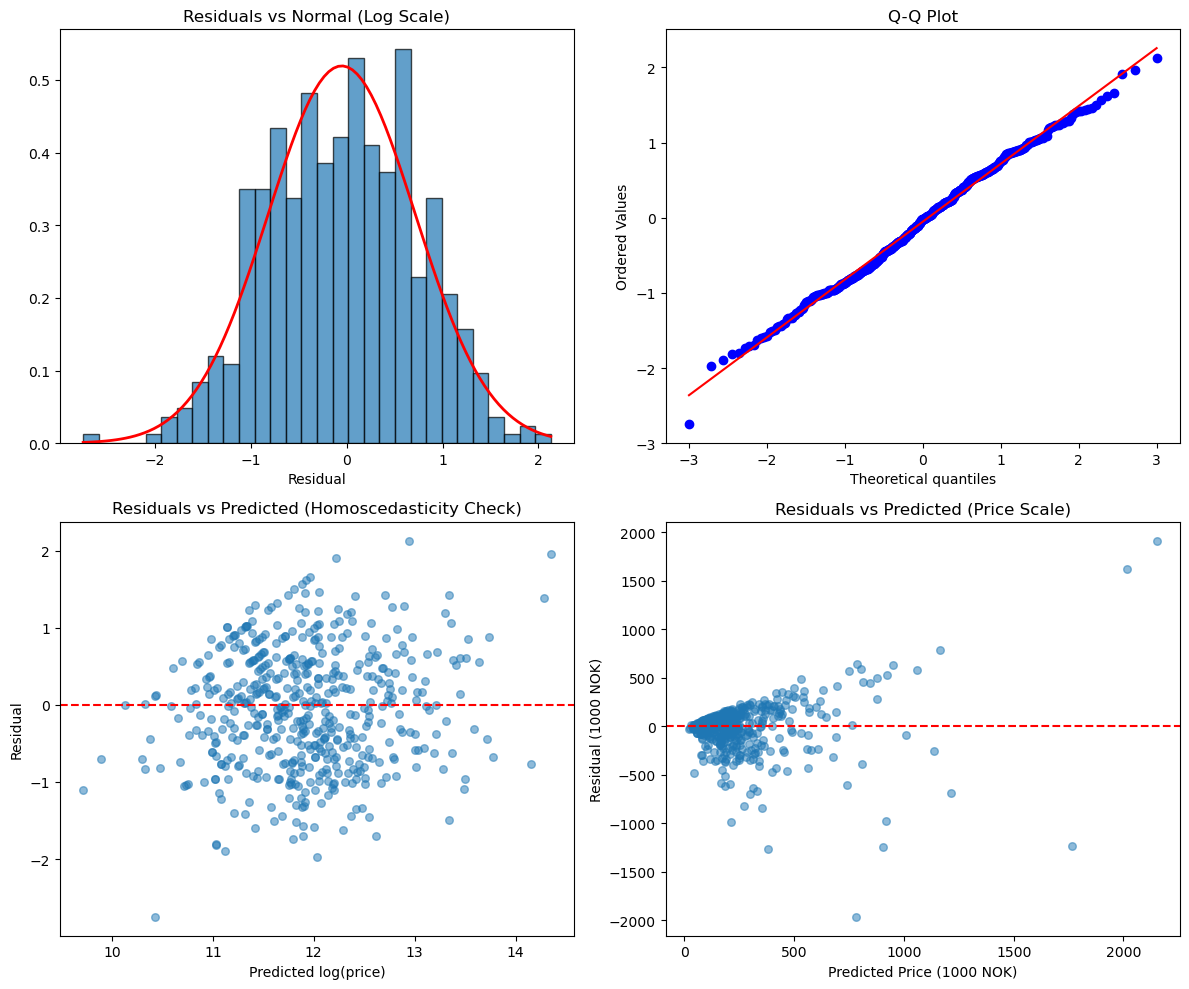

In [75]:
# =========================================================
# RESIDUAL ANALYSIS
# =========================================================
from scipy import stats

print("="*70)
print("RESIDUAL ANALYSIS")
print("="*70)

residuals_log = pred_test - y_test.values 
residuals_price = pred_test_price - y_test_price

# Descriptive statistics
print(f"\n[LOG SCALE RESIDUALS]")
print(f"  Mean:     {np.mean(residuals_log):.4f}")
print(f"  Median:     {np.median(residuals_log):.4f}")
print(f"  Std:      {np.std(residuals_log):.4f}")
print(f"  Skewness: {stats.skew(residuals_log):.4f}")
print(f"  Kurtosis: {stats.kurtosis(residuals_log):.4f}")

print(f"\n[PRICE SCALE RESIDUALS]")
print(f"  Mean:     {np.mean(residuals_price):+,.0f} NOK")
print(f"  Median:   {np.median(residuals_price):+,.0f} NOK")

# Normality tests
print(f"\n[NORMALITY TESTS - LOG SCALE]")
if len(residuals_log) <= 5000:
    stat_sw, p_sw = stats.shapiro(residuals_log)
    result_sw = "Normal ✓" if p_sw > 0.05 else "Not Normal ✗"
    print(f"  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} → {result_sw}")

stat_jb, p_jb = stats.jarque_bera(residuals_log)
result_jb = "Normal ✓" if p_jb > 0.05 else "Not Normal ✗"
print(f"  Jarque-Bera: JB={stat_jb:.4f}, p={p_jb:.4f} → {result_jb}")

# Interpretation
skewness = stats.skew(residuals_log)
kurtosis = stats.kurtosis(residuals_log)

print(f"\n[INTERPRETATION]")
if abs(skewness) < 0.5:
    print(f"  Skewness ({skewness:.2f}): Approximately symmetric ✓")
else:
    print(f"  Skewness ({skewness:.2f}): {'Right' if skewness > 0 else 'Left'}-skewed")

if abs(kurtosis) < 1:
    print(f"  Kurtosis ({kurtosis:.2f}): Near normal tails ✓")
else:
    print(f"  Kurtosis ({kurtosis:.2f}): {'Heavy' if kurtosis > 0 else 'Light'} tails")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histogram
ax1 = axes[0, 0]
ax1.hist(residuals_log, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(residuals_log.min(), residuals_log.max(), 100)
ax1.plot(x, stats.norm.pdf(x, np.mean(residuals_log), np.std(residuals_log)), 'r-', lw=2)
ax1.set_title('Residuals vs Normal (Log Scale)')
ax1.set_xlabel('Residual')

# Q-Q plot
ax2 = axes[0, 1]
stats.probplot(residuals_log, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot')

# Residuals vs Predicted
ax3 = axes[1, 0]
ax3.scatter(pred_test, residuals_log, alpha=0.5, s=30)
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted log(price)')
ax3.set_ylabel('Residual')
ax3.set_title('Residuals vs Predicted (Homoscedasticity Check)')

# Residuals vs Fitted (price scale)
ax4 = axes[1, 1]
ax4.scatter(pred_test_price/1000, residuals_price/1000, alpha=0.5, s=30)
ax4.axhline(y=0, color='r', linestyle='--')
ax4.set_xlabel('Predicted Price (1000 NOK)')
ax4.set_ylabel('Residual (1000 NOK)')
ax4.set_title('Residuals vs Predicted (Price Scale)')

plt.tight_layout()
plt.savefig('LR_residual_analysis.svg', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(y_test, pred_test, alpha=0.5, s=30)

# 45-degree reference line
min_val = min(y_test.min(), pred_test.min())
max_val = max(y_test.max(), pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual log(price)")
plt.ylabel("Predicted log(price)")
plt.title("Linear reg - Predicted vs Actual Prices (Log Scale)")

plt.tight_layout()
plt.savefig('Predicted VS Actual prices.svg', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# =========================================================
# PREDICTIONS FOR EACH HORSE IN TEST SET
# =========================================================

print("="*70)
print("INDIVIDUAL HORSE PREDICTIONS")
print("="*70)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Actual_Price_NOK': np.exp(y_test),
    'Predicted_Price_NOK': pred_test_price,
    'Error_NOK': pred_test_price - np.exp(y_test),
    'Error_Pct': ((pred_test_price - np.exp(y_test)) / np.exp(y_test)) * 100,
    'Abs_Error_NOK': np.abs(pred_test_price - np.exp(y_test)),
    'Abs_Error_Pct': np.abs((pred_test_price - np.exp(y_test)) / np.exp(y_test)) * 100,
    'Log_Actual': y_test,
    'Log_Predicted': pred_test
}, index=y_test.index)

# Add horse identifiers if available in original dataframe
# Try to add horse name, year, auction, and other identifiers
identifier_cols = ['Horse', 'Name', col_year, col_auction, col_gender, col_age]
for col in identifier_cols:
    if col and col in df.columns:
        predictions_df[col] = df.loc[y_test.index, col]

# Sort by absolute error (worst predictions first)
predictions_df_sorted = predictions_df.sort_values('Abs_Error_NOK', ascending=False)

print(f"\nTotal predictions: {len(predictions_df)}")
print(f"\n[SUMMARY STATISTICS]")
print(f"  Mean Absolute Error:    {predictions_df['Abs_Error_NOK'].mean():,.0f} NOK")
print(f"  Median Absolute Error:  {predictions_df['Abs_Error_NOK'].median():,.0f} NOK")
print(f"  Mean Error %:           {predictions_df['Error_Pct'].mean():.1f}%")
print(f"  Median Abs Error %:     {predictions_df['Abs_Error_Pct'].median():.1f}%")

print(f"\n[TOP 10 WORST PREDICTIONS - OVERPRICED]")
print("(Model predicted higher than actual price)")
overpriced = predictions_df_sorted[predictions_df_sorted['Error_NOK'] > 0].head(10)
for idx, row in overpriced.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

print(f"\n[TOP 10 WORST PREDICTIONS - UNDERPRICED]")
print("(Model predicted lower than actual price)")
underpriced = predictions_df_sorted[predictions_df_sorted['Error_NOK'] < 0].head(10)
for idx, row in underpriced.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

print(f"\n[BEST 10 PREDICTIONS]")
best = predictions_df.sort_values('Abs_Error_NOK').head(10)
for idx, row in best.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

# Save to CSV
predictions_df_sorted.to_csv('linear_regression_predictions.csv', index=True)
print(f"\n✓ Predictions saved to linear_regression_predictions.csv")

# Display first few rows
print(f"\n[FIRST 20 PREDICTIONS]")
display_cols = ['Actual_Price_NOK', 'Predicted_Price_NOK', 'Error_NOK', 'Error_Pct']
if col_year in predictions_df.columns:
    display_cols.insert(0, col_year)
print(predictions_df_sorted[display_cols].head(20).to_string())

In [ ]:
predictions_df.to_excel("LINEAR_REGRESSION_2025.xlsx", index=True)

In [ ]:
# =========================================================
# ANALYZE PRICE BUILD-UP FOR A SINGLE HORSE
# =========================================================

def analyze_horse_prediction(horse_index, show_top_n=12):
    """
    Break down the price prediction for a single horse.
    Shows how each feature contributes to the final predicted price.
    
    Parameters:
    -----------
    horse_index : int
        Index of the horse in the test set
    show_top_n : int
        Number of top positive and negative contributors to show
    """
    
    if horse_index not in y_test.index:
        print(f"Error: Index {horse_index} not found in test set")
        return
    
    print("="*70)
    print(f"PRICE BUILD-UP ANALYSIS FOR HORSE INDEX {horse_index}")
    print("="*70)
    
    # Get the horse's features
    horse_features = X_test.loc[horse_index]
    
    # Get identifiers if available
    print("\n[HORSE INFORMATION]")
    identifier_cols = ['Horse', 'Name', col_year, col_auction, col_gender, col_age]
    for col in identifier_cols:
        if col and col in df.columns:
            print(f"  {col}: {df.loc[horse_index, col]}")
    
    # Actual vs Predicted
    actual_price = np.exp(y_test.loc[horse_index])
    predicted_log = pred_test[y_test.index.get_loc(horse_index)]
    predicted_price = pred_test_price[y_test.index.get_loc(horse_index)]
    error_pct = ((predicted_price - actual_price) / actual_price) * 100
    
    print(f"\n[PRICES]")
    print(f"  Actual Price:    {actual_price:>12,.0f} NOK")
    print(f"  Predicted Price: {predicted_price:>12,.0f} NOK")
    print(f"  Error:           {predicted_price - actual_price:>12,.0f} NOK ({error_pct:+.1f}%)")
    
    # Calculate feature contributions
    print(f"\n[PREDICTION BUILD-UP IN LOG SCALE]")
    print(f"  Base (Intercept):     {model.intercept_:>8.4f}")
    
    contributions = []
    for i, feature in enumerate(FEATURES):
        feature_value = horse_features[feature]
        coefficient = model.coef_[i]
        contribution = feature_value * coefficient
        contributions.append({
            'Feature': feature,
            'Value': feature_value,
            'Coefficient': coefficient,
            'Contribution': contribution
        })
    
    contrib_df = pd.DataFrame(contributions)
    contrib_df = contrib_df.sort_values('Contribution', ascending=False)
    
    # Show top positive contributors
    print(f"\n[TOP {show_top_n} POSITIVE CONTRIBUTORS (increasing price)]")
    print(f"{'Feature':<30} {'Value':<15} {'Coef':<10} {'Contribution':>12}")
    print("-"*70)
    for _, row in contrib_df.head(show_top_n).iterrows():
        if row['Contribution'] > 0:
            value_str = f"{row['Value']:.3f}" if abs(row['Value']) < 100 else f"{row['Value']:.0f}"
            print(f"{row['Feature']:<30} {value_str:<15} {row['Coefficient']:>9.4f} {row['Contribution']:>12.4f}")
    
    # Show top negative contributors
    print(f"\n[TOP {show_top_n} NEGATIVE CONTRIBUTORS (decreasing price)]")
    print(f"{'Feature':<30} {'Value':<15} {'Coef':<10} {'Contribution':>12}")
    print("-"*70)
    for _, row in contrib_df.tail(show_top_n).iloc[::-1].iterrows():
        if row['Contribution'] < 0:
            value_str = f"{row['Value']:.3f}" if abs(row['Value']) < 100 else f"{row['Value']:.0f}"
            print(f"{row['Feature']:<30} {value_str:<15} {row['Coefficient']:>9.4f} {row['Contribution']:>12.4f}")
    
    # Sum it all up
    total_contribution = contrib_df['Contribution'].sum()
    predicted_log_manual = model.intercept_ + total_contribution
    
    print(f"\n[PREDICTION CALCULATION]")
    print(f"  Intercept:                    {model.intercept_:>10.4f}")
    print(f"  + Sum of contributions:       {total_contribution:>10.4f}")
    print(f"  = Predicted log(price):       {predicted_log_manual:>10.4f}")
    print(f"  (Actual predicted log):       {predicted_log:>10.4f}")
    
    # Convert to price scale
    predicted_price_manual = np.exp(predicted_log_manual) * np.exp(sigma2 / 2)
    print(f"\n[PRICE SCALE CONVERSION]")
    print(f"  exp({predicted_log_manual:.4f}) = {np.exp(predicted_log_manual):,.0f} NOK")
    print(f"  × bias correction ({np.exp(sigma2/2):.4f}) = {predicted_price_manual:,.0f} NOK")
    print(f"  (Actual predicted price: {predicted_price:,.0f} NOK)")
    
    # Feature importance for this horse
    contrib_df['Abs_Contribution'] = contrib_df['Contribution'].abs()
    contrib_df_sorted = contrib_df.sort_values('Abs_Contribution', ascending=False)
    
    print(f"\n[MOST IMPACTFUL FEATURES FOR THIS HORSE]")
    print(f"(by absolute contribution)")
    print(f"{'Feature':<30} {'Impact':>12}")
    print("-"*45)
    for _, row in contrib_df_sorted.head(10).iterrows():
        print(f"{row['Feature']:<30} {row['Contribution']:>+12.4f}")
    
    return contrib_df


# Example usage - analyze a horse from test set
# You can change this index to analyze different horses
example_horse_index = y_test.index[416]  # First horse in test set

print("Example: Analyzing first horse in test set...\n")
contrib_data = analyze_horse_prediction(example_horse_index)

print("\n" + "="*70)
print("To analyze other horses, use:")
print("  analyze_horse_prediction(horse_index)")
print("\nAvailable test set indices:")
print(f"  {list(y_test.index[:10])} ... (showing first 10)")

In [ ]:
# =========================================================
# TOP-DECILE ACCURACY METRICS
# =========================================================

import numpy as np
import pandas as pd

print("="*70)
print("TOP-DECILE ACCURACY ANALYSIS")
print("="*70)

# =========================================================
# 1. DEFINE TOP-DECILE THRESHOLDS
# =========================================================

# Training data
top_decile_threshold_train = np.percentile(y_train_price, 90)
print(f"\n[TOP-DECILE THRESHOLDS]")
print(f"  Training (90th percentile): {top_decile_threshold_train:>12,.0f} NOK")

# Test data
top_decile_threshold_test = np.percentile(y_test_price, 90)
print(f"  Test (90th percentile):     {top_decile_threshold_test:>12,.0f} NOK")

# =========================================================
# 2. IDENTIFY TOP-DECILE HORSES
# =========================================================

# Actual top-decile (ground truth)
actual_top_decile_train = y_train_price >= top_decile_threshold_train
actual_top_decile_test = y_test_price >= top_decile_threshold_test

# Predicted top-decile (based on model)
pred_top_decile_train = pred_train_price >= top_decile_threshold_train
pred_top_decile_test = pred_test_price >= top_decile_threshold_test

print(f"\n[TOP-DECILE COUNTS]")
print(f"  Training: {actual_top_decile_train.sum()} actual, {pred_top_decile_train.sum()} predicted")
print(f"  Test:     {actual_top_decile_test.sum()} actual, {pred_top_decile_test.sum()} predicted")

# =========================================================
# 3. PRECISION AND RECALL
# =========================================================

from sklearn.metrics import precision_score, recall_score, f1_score

print(f"\n[TOP-DECILE CLASSIFICATION METRICS]")

# Training
precision_train = precision_score(actual_top_decile_train, pred_top_decile_train)
recall_train = recall_score(actual_top_decile_train, pred_top_decile_train)
f1_train = f1_score(actual_top_decile_train, pred_top_decile_train)

print(f"\n  Training:")
print(f"    Precision: {precision_train:.3f}  (Of predicted top-10%, {precision_train*100:.1f}% are actually top-10%)")
print(f"    Recall:    {recall_train:.3f}  (Of actual top-10%, {recall_train*100:.1f}% were identified)")
print(f"    F1-Score:  {f1_train:.3f}")

# Test
precision_test = precision_score(actual_top_decile_test, pred_top_decile_test)
recall_test = recall_score(actual_top_decile_test, pred_top_decile_test)
f1_test = f1_score(actual_top_decile_test, pred_top_decile_test)

print(f"\n  Test:")
print(f"    Precision: {precision_test:.3f}  (Of predicted top-10%, {precision_test*100:.1f}% are actually top-10%)")
print(f"    Recall:    {recall_test:.3f}  (Of actual top-10%, {recall_test*100:.1f}% were identified)")
print(f"    F1-Score:  {f1_test:.3f}")

# =========================================================
# 4. CONFUSION MATRIX FOR TOP-DECILE
# =========================================================

from sklearn.metrics import confusion_matrix

print(f"\n[TOP-DECILE CONFUSION MATRIX - Test Set]")

cm = confusion_matrix(actual_top_decile_test, pred_top_decile_test)

print(f"\n                    Predicted")
print(f"                 Not Top-10%  Top-10%")
print(f"Actual Not Top   {cm[0,0]:>11}  {cm[0,1]:>8}")
print(f"Actual Top-10%   {cm[1,0]:>11}  {cm[1,1]:>8}")

# Calculate rates
tn, fp, fn, tp = cm.ravel()
print(f"\n  True Positives (TP):  {tp:>4}  (Correctly identified as top-10%)")
print(f"  False Positives (FP): {fp:>4}  (Predicted top-10% but not)")
print(f"  True Negatives (TN):  {tn:>4}  (Correctly identified as not top-10%)")
print(f"  False Negatives (FN): {fn:>4}  (Missed actual top-10%)")

# =========================================================
# 5. TOP-DECILE SPECIFIC ERROR METRICS
# =========================================================

print(f"\n[ERROR METRICS FOR TOP-DECILE HORSES]")

# Test set - only top-decile horses
top_decile_mask_test = actual_top_decile_test
if top_decile_mask_test.sum() > 0:
    
    # Price errors for top-decile
    actual_top = y_test_price[top_decile_mask_test]
    pred_top = pred_test_price[top_decile_mask_test]
    
    mape_top = np.mean(np.abs((actual_top - pred_top) / actual_top)) * 100
    mdape_top = np.median(np.abs((actual_top - pred_top) / actual_top)) * 100
    rmse_top = np.sqrt(np.mean((actual_top - pred_top)**2))
    mae_top = np.mean(np.abs(actual_top - pred_top))
    mean_error_top = np.mean(actual_top - pred_top)
    
    print(f"\n  Test Set - Top-Decile Only (n={top_decile_mask_test.sum()}):")
    print(f"    MAPE:        {mape_top:.1f}%")
    print(f"    MdAPE:       {mdape_top:.1f}%")
    print(f"    RMSE:        {rmse_top:,.0f} NOK")
    print(f"    MAE:         {mae_top:,.0f} NOK")
    print(f"    Mean Error:  {mean_error_top:+,.0f} NOK")
    
    # Compare to overall test set
    mape_overall = np.mean(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100
    mdape_overall = np.median(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100
    
    print(f"\n  Comparison to Overall Test Set:")
    print(f"    Top-10% MdAPE:  {mdape_top:.1f}%")
    print(f"    Overall MdAPE:  {mdape_overall:.1f}%")
    print(f"    Difference:     {mdape_top - mdape_overall:+.1f}%")
    
    if mdape_top < mdape_overall:
        print(f"    ✓ Model is MORE accurate for expensive horses")
    else:
        print(f"    ⚠ Model is LESS accurate for expensive horses")

# =========================================================
# 6. HIT RATE ANALYSIS
# =========================================================

print(f"\n[HIT RATE ANALYSIS]")
print("  (If you bid on predicted top-10%, what do you get?)")

# Get top N predictions
n_top = actual_top_decile_test.sum()  # Number of actual top-decile horses

# Sort by predicted price
test_indices = np.argsort(pred_test_price)[::-1]  # Descending order
top_n_predicted = test_indices[:n_top]

# How many are actually in top-decile?
hits = actual_top_decile_test.iloc[top_n_predicted].sum()
hit_rate = hits / n_top

print(f"\n  Strategy: Bid on top {n_top} horses (by predicted price)")
print(f"  Result:   {hits} out of {n_top} are actually top-10%")
print(f"  Hit Rate: {hit_rate:.1%}")

# Average price of horses we'd bid on
avg_actual_price_bid = y_test_price.iloc[top_n_predicted].mean()
avg_pred_price_bid = pred_test_price[top_n_predicted].mean()

print(f"\n  Horses we'd bid on:")
print(f"    Avg predicted price: {avg_pred_price_bid:>12,.0f} NOK")
print(f"    Avg actual price:    {avg_actual_price_bid:>12,.0f} NOK")
print(f"    Difference:          {avg_actual_price_bid - avg_pred_price_bid:>12,.0f} NOK")

# =========================================================
# 7. RANK CORRELATION
# =========================================================

from scipy.stats import spearmanr, kendalltau

print(f"\n[RANK CORRELATION]")
print("  (How well does model rank horses from cheap to expensive?)")

spearman_corr, spearman_p = spearmanr(y_test_price, pred_test_price)
kendall_corr, kendall_p = kendalltau(y_test_price, pred_test_price)

print(f"\n  Spearman Correlation: {spearman_corr:.4f} (p={spearman_p:.4e})")
print(f"  Kendall Tau:          {kendall_corr:.4f} (p={kendall_p:.4e})")

if spearman_corr > 0.7:
    print(f"  ✓ Excellent ranking ability")
elif spearman_corr > 0.5:
    print(f"  ~ Good ranking ability")
else:
    print(f"  ⚠ Moderate ranking ability")

# =========================================================
# 8. TOP-K ACCURACY (VARYING K)
# =========================================================

print(f"\n[TOP-K ACCURACY FOR DIFFERENT K VALUES]")
print(f"{'Top-K':<10} {'Actual in K':<15} {'Hit Rate':<12} {'Precision'}")
print(f"{'-'*10} {'-'*15} {'-'*12} {'-'*12}")

for k_pct in [5, 10, 15, 20, 25]:
    k = int(len(y_test_price) * k_pct / 100)
    
    # Get top-k by prediction
    top_k_indices = np.argsort(pred_test_price)[::-1][:k]
    
    # Threshold for actual top-k
    threshold_k = np.percentile(y_test_price, 100 - k_pct)
    actual_top_k = y_test_price >= threshold_k
    
    # How many of predicted top-k are actually top-k?
    hits_k = actual_top_k.iloc[top_k_indices].sum()
    hit_rate_k = hits_k / k
    
    print(f"Top-{k_pct:>2}%    {hits_k:>5}/{k:<7}    {hit_rate_k:>11.1%}    {hit_rate_k:.3f}")

# =========================================================
# 9. VISUALIZATION
# =========================================================

print(f"\n[CREATING VISUALIZATIONS]")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Scatter with top-decile highlighted
ax1 = axes[0, 0]
# Regular horses
mask_regular = ~actual_top_decile_test
ax1.scatter(y_test_price[mask_regular]/1000, 
            pred_test_price[mask_regular]/1000,
            alpha=0.3, s=30, label='Bottom 90%', color='blue')
# Top-decile horses
ax1.scatter(y_test_price[actual_top_decile_test]/1000,
            pred_test_price[actual_top_decile_test]/1000,
            alpha=0.6, s=50, label='Top 10%', color='red')
# Perfect prediction line
max_price = y_test_price.max() / 1000
ax1.plot([0, max_price], [0, max_price], 'k--', lw=2, alpha=0.5)
# Threshold lines
ax1.axvline(x=top_decile_threshold_test/1000, color='red', linestyle=':', lw=2)
ax1.axhline(y=top_decile_threshold_test/1000, color='red', linestyle=':', lw=2)
ax1.set_xlabel('Actual Price (1000 NOK)')
ax1.set_ylabel('Predicted Price (1000 NOK)')
ax1.set_title('Top-Decile Identification')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix Heatmap
ax2 = axes[0, 1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax2.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_yticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Top-Decile Confusion Matrix (Normalized)')
# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                       ha="center", va="center", color="black", fontsize=12)
plt.colorbar(im, ax=ax2)

# Plot 3: Top-K Accuracy Curve
ax3 = axes[1, 0]
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
hit_rates = []
for k_pct in k_values:
    k = int(len(y_test_price) * k_pct / 100)
    top_k_indices = np.argsort(pred_test_price)[::-1][:k]
    threshold_k = np.percentile(y_test_price, 100 - k_pct)
    actual_top_k = y_test_price >= threshold_k
    hits_k = actual_top_k.iloc[top_k_indices].sum()
    hit_rates.append(hits_k / k)

ax3.plot(k_values, hit_rates, marker='o', linewidth=2, markersize=8)
ax3.axhline(y=1.0, color='green', linestyle='--', label='Perfect')
ax3.set_xlabel('Top-K%')
ax3.set_ylabel('Hit Rate')
ax3.set_title('Hit Rate by Top-K Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# Plot 4: Error by Price Decile
ax4 = axes[1, 1]
decile_labels = []
decile_mdapes = []
for i in range(10):
    lower = np.percentile(y_test_price, i*10)
    upper = np.percentile(y_test_price, (i+1)*10)
    mask = (y_test_price >= lower) & (y_test_price < upper)
    if mask.sum() > 0:
        apes = np.abs((y_test_price[mask] - pred_test_price[mask]) / y_test_price[mask]) * 100
        decile_mdapes.append(np.median(apes))
        decile_labels.append(f'D{i+1}')

ax4.bar(range(len(decile_labels)), decile_mdapes, color='steelblue', alpha=0.7)
ax4.axhline(y=mdape_overall, color='red', linestyle='--', lw=2, label=f'Overall: {mdape_overall:.1f}%')
ax4.set_xlabel('Price Decile (D1=Cheapest, D10=Most Expensive)')
ax4.set_ylabel('MdAPE (%)')
ax4.set_title('Prediction Accuracy by Price Decile')
ax4.set_xticks(range(len(decile_labels)))
ax4.set_xticklabels(decile_labels)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('top_decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("  ✓ Saved: top_decile_analysis.png")

# =========================================================
# 10. EXPORT SUMMARY
# =========================================================

print(f"\n[EXPORTING SUMMARY]")

top_decile_summary = pd.DataFrame({
    'Metric': [
        'Top-Decile Threshold',
        'Precision',
        'Recall',
        'F1-Score',
        'Hit Rate',
        'Top-Decile MdAPE',
        'Overall MdAPE',
        'Spearman Correlation',
    ],
    'Test': [
        f'{top_decile_threshold_test:,.0f} NOK',
        f'{precision_test:.3f}',
        f'{recall_test:.3f}',
        f'{f1_test:.3f}',
        f'{hit_rate:.1%}',
        f'{mdape_top:.1f}%',
        f'{mdape_overall:.1f}%',
        f'{spearman_corr:.4f}',
    ]
})

top_decile_summary.to_excel('top_decile_metrics.xlsx', index=False)
print("  ✓ Saved: top_decile_metrics.xlsx")

print("\n" + "="*70)
print("TOP-DECILE ANALYSIS COMPLETE")
print("="*70)

In [ ]:
# ---------------------------------------------------------
# A) NDCG CALCULATION
# ---------------------------------------------------------

def dcg_at_k(relevance, k):
    """Discounted Cumulative Gain at position k."""
    relevance = np.array(relevance[:k], dtype=float)
    positions = np.arange(1, len(relevance) + 1)
    return np.sum(relevance / np.log2(positions + 1))


def ndcg_at_k(y_true, y_pred, k):
    """
    NDCG@k: Sort items by predicted score, evaluate
    ranking quality using actual values as relevance.
    """
    pred_order = np.argsort(y_pred)[::-1]
    actual_ranked_by_pred = y_true[pred_order]

    ideal_order = np.argsort(y_true)[::-1]
    ideal_relevance = y_true[ideal_order]

    dcg = dcg_at_k(actual_ranked_by_pred, k)
    idcg = dcg_at_k(ideal_relevance, k)

    return dcg / idcg if idcg > 0 else 0.0


# --- Compute NDCG at multiple K values ---
n_test = len(y_test)

y_test_price_arr = np.exp(y_test.values)
pred_test_price_arr = pred_test_price
y_test_log_arr = y_test.values
pred_test_log_arr = pred_test

k_configs = [
    ("Top 10%", max(1, int(n_test * 0.10))),
    ("Top 20%", max(1, int(n_test * 0.20))),
    ("Top 50%", max(1, int(n_test * 0.50))),
    ("Full",    n_test),
]

print(f"\n[NDCG — PRICE SCALE RELEVANCE]")
print(f"  {'K':<12} {'n':>6} {'NDCG':>10}")
print(f"  {'-'*12} {'-'*6} {'-'*10}")

ndcg_results = []
for label, k in k_configs:
    ndcg = ndcg_at_k(y_test_price_arr, pred_test_price_arr, k)
    ndcg_results.append({"K": label, "n": k, "NDCG": ndcg})
    print(f"  {label:<12} {k:>6} {ndcg:>10.4f}")

print(f"\n[NDCG — LOG SCALE RELEVANCE]")
print(f"  {'K':<12} {'n':>6} {'NDCG':>10}")
print(f"  {'-'*12} {'-'*6} {'-'*10}")

for label, k in k_configs:
    ndcg = ndcg_at_k(y_test_log_arr, pred_test_log_arr, k)
    print(f"  {label:<12} {k:>6} {ndcg:>10.4f}")

ndcg_full = ndcg_results[-1]["NDCG"]
ndcg_top10 = ndcg_results[0]["NDCG"]

print(f"\n[INTERPRETATION]")
if ndcg_full > 0.95:
    print(f"  NDCG@Full = {ndcg_full:.4f}: Excellent overall ranking")
elif ndcg_full > 0.90:
    print(f"  NDCG@Full = {ndcg_full:.4f}: Good overall ranking")
else:
    print(f"  NDCG@Full = {ndcg_full:.4f}: Moderate overall ranking")

if ndcg_top10 > 0.90:
    print(f"  NDCG@10%  = {ndcg_top10:.4f}: Excellent at identifying top horses")
elif ndcg_top10 > 0.80:
    print(f"  NDCG@10%  = {ndcg_top10:.4f}: Good at identifying top horses")
else:
    print(f"  NDCG@10%  = {ndcg_top10:.4f}: Moderate at identifying top horses")

spearman_corr, spearman_p = spearmanr(y_test_price_arr, pred_test_price_arr)
print(f"\n  Spearman ρ = {spearman_corr:.4f} (p = {spearman_p:.2e}) for reference")